In [1]:
# These take a while

!pip install --upgrade "typing_extensions>=4.10.0"
!pip install --upgrade pip
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
!pip install -q bitsandbytes sae-lens datasets matplotlib tqdm scipy seaborn scikit-learn numpy accelerate statsmodels
!pip install -q transformers accelerate
!pip install -q hf_transfer

print("Done")

  Attempting uninstall: typing_extensions
    Found existing installation: typing_extensions 4.9.0
    Uninstalling typing_extensions-4.9.0:
      Successfully uninstalled typing_extensions-4.9.0

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 187.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.4.1+cu124 requires torch==2.4.1, but you have torch 2.12.0 which is incompatible.
torchvision 0.19.1+cu124 requires torch==2.4.1, but you have torch 2.12.0 which is incompatible.
Done


In [1]:
# === ONLY install cell. Run once, RESTART KERNEL, then run imports. ===
%pip install --upgrade pip
%pip install -U "typing_extensions>=4.10.0"

# Torch 2.7+ — needed for torch.float8_e8m0fnu that current transformers references.
# cu128 wheels cover the L40S. This REPLACES the old cu124 line that capped you at 2.6.
%pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

# Everything the notebook imports, one resolve, bitsandbytes last so it matches torch.
# No transformer-lens pin — sae-lens pulls its own compatible version.
%pip install -U sae-lens transformers accelerate datasets hf_transfer bitsandbytes
%pip install -U matplotlib tqdm scipy seaborn scikit-learn numpy statsmodels

print("Install done. RESTART THE KERNEL now, then run the imports cell.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 90.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2
Note: you may need to restart the kernel to use updated packages.
  Attempting uninstall: typing_extensions
    Found existing installation: typing_extensions 4.9.0
    Uninstalling typing_extensions-4.9.0:
      Successfully uninstalled typing_extensions-4.9.0
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.9/657.9 MB 723.8 MB/s  0:00:01a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 722.2 MB/s  0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 677.8 MB/s  0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 MB 541.8 MB/s  0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import torch
print(torch.__version__, "| float8_e8m0fnu present:", hasattr(torch, "float8_e8m0fnu"))
print("CUDA:", torch.cuda.is_available())

2.11.0+cu128 | float8_e8m0fnu present: True
CUDA: True


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
from sae_lens import SAE
from datasets import load_dataset
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import re
import gc

In [3]:
from huggingface_hub import login
login()

In [8]:
# Setup device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

MODEL_A_ID = "google/gemma-2-2b"     
MODEL_B_ID = "google/gemma-2-9b"    

# Fixed layer pair based on previous calculations
STITCH_LAYER_A = 20   # Gemma 2B layer 20
STITCH_LAYER_B = 30  # Gemma 9B layer 30

SAE_A_RELEASE = "gemma-scope-2b-pt-res-canonical"
SAE_A_ID = f"layer_{STITCH_LAYER_A}/width_16k/canonical"  
SAE_B_RELEASE = "gemma-scope-9b-pt-res-canonical" 
SAE_B_ID = f"layer_{STITCH_LAYER_B}/width_16k/canonical" 

# [Phase 0] Oracle deltas are now collected from GSM8K-train (indices 0..N_ORACLE_SAMPLES-1),
# which is disjoint from the GSM8K test split used for evaluation.
# [Phase 1] Training data switched from OpenWebText to GSM8K-train.
TRAINING_DATASET = "openai/gsm8k"          # replaces NeelNanda/openwebtext-tokenized-9b
TRAINING_DATASET_CONFIG = "main"
TRAINING_SPLIT = "train"            # GSM8K train has ~7.5k examples
N_TRAINING_SAMPLES = 5000           # how many GSM8K-train examples to tokenize

CONTEXT_LENGTH = 128
BATCH_SIZE = 4  
NUM_EPOCHS = 8   
LEARNING_RATE = 1e-4
ACTIVATION_CACHE_SIZE = 5_000  
NUM_SAMPLES_FOR_SVCCA = 200  

# ── Phase 1 training config flags ──────────────────────────────────────────
# Bottleneck width (Phase 3 sweep: try 32, 64, 128, 256)
BOTTLENECK_DIM = 64

# Set to 0.0 to use KL-only loss (recommended default per analysis in doc).
# Set to 0.5 to restore original cycle-consistency weighting for ablation.
# Phase 3 ablation: run with CYCLE_LOSS_WEIGHT=0.5 to compare curves.
CYCLE_LOSS_WEIGHT = 0.0

# Random per-batch strength sampling range (uniform draw each batch).
# Recommended: [0.3, 1.0]. Matches the hook used at eval time.
STRENGTH_SAMPLE_MIN = 0.3
STRENGTH_SAMPLE_MAX = 1.0

# Oracle-in-training: keep False so the trained stitch isn't coupled to a
# specific oracle rank -> Phase 3's rank sweep works from one trained stitch.
# Flip to True in Phase 3 if you want to test oracle-guided training.
APPLY_ORACLE_IN_TRAINING = False

# Number of GSM8K-train samples used for oracle delta collection (Phase 0).
# These indices MUST NOT overlap with evaluation indices (GSM8K test split).
# GSM8K train and test are separate HF splits, so there is zero overlap.
N_ORACLE_SAMPLES = 100


ORACLE_RANK_FOR_TRAINING = 32   # set based on Phase 1 sweep results

Using device: cuda


In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

print("Loading tokenizer and models...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_A_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'   # required for correct batched generate at eval

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True
)

# Load Model A (2B model)
print(f"Loading {MODEL_A_ID}...")
model_a = AutoModelForCausalLM.from_pretrained(
    MODEL_A_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True
)

# Load Model B (9B model)
print(f"Loading {MODEL_B_ID}...")
model_b = AutoModelForCausalLM.from_pretrained(
    MODEL_B_ID,
    torch_dtype=torch.bfloat16,
    quantization_config=bnb_config,  # <-- NEW WAY TO PASS 4-BIT PARAMS
    device_map="auto",
    low_cpu_mem_usage=True
)

print("Models and tokenizer loaded successfully.")
print(f"Using fixed layer pair: Gemma 2B Layer {STITCH_LAYER_A} → Gemma 9B Layer {STITCH_LAYER_B}")

def get_unnormalized_activations(model, tokens, layer_idx, return_all_positions=False):
    """
    Get unnormalized activations. Can return all positions or just the last token.
    """
    with torch.no_grad():
        # Handle different model architectures
        if hasattr(model, 'model'):
            # For Gemma models
            outputs = model.model(tokens, output_hidden_states=True)
        else:
            outputs = model(tokens, output_hidden_states=True)
        
        # Shape: [batch_size, seq_len, hidden_dim]
        all_activations = outputs.hidden_states[layer_idx].to(torch.float32)
        
        if return_all_positions:
            # Return all sequence positions: [batch_size * seq_len, hidden_dim]
            batch_size, seq_len, hidden_dim = all_activations.shape
            return all_activations.view(-1, hidden_dim).cpu()
        else:
            # Return only last token: [batch_size, hidden_dim] 
            return all_activations[:, -1].cpu()

def get_normalized_activations(model, tokens, layer_idx, return_all_positions=False):
    """
    Get normalized activations. Can return all positions or just the last token.
    """
    with torch.no_grad():
        if hasattr(model, 'model'):
            outputs = model.model(tokens, output_hidden_states=True)
        else:
            outputs = model(tokens, output_hidden_states=True)
            
        # Shape: [batch_size, seq_len, hidden_dim]
        all_activations = outputs.hidden_states[layer_idx].to(torch.float32)
        
        if return_all_positions:
            # Normalize per position, return all: [batch_size * seq_len, hidden_dim]
            batch_size, seq_len, hidden_dim = all_activations.shape
            # Reshape to process all positions at once
            reshaped = all_activations.view(-1, hidden_dim)
            normalized = torch.nn.functional.layer_norm(reshaped, [hidden_dim])
            return normalized.cpu()
        else:
            # Normalize and return only last token: [batch_size, hidden_dim]
            last_token_acts = all_activations[:, -1]  
            normalized_activations = torch.nn.functional.layer_norm(last_token_acts, [last_token_acts.shape[-1]])
            return normalized_activations.cpu()
        
        
def get_sae_features(model, sae, tokens, layer_idx):
    """Get SAE feature activations instead of raw activations"""
    with torch.no_grad():
        # Get unnormalized activations (SAEs expect these)
        if hasattr(model, 'model'):
            outputs = model.model(tokens, output_hidden_states=True)
        else:
            outputs = model(tokens, output_hidden_states=True)
        
        activations = outputs.hidden_states[layer_idx].to(torch.float32)
        
        # Encode through SAE to get features
        features = sae.encode(activations[:, -1])  # [batch, d_sae]
        return features.cpu()



def centered_kernel_alignment(acts_a, acts_b, device):
    """
    Centered Kernel Alignment (CKA) for similarity measurement
    """
    acts_a = acts_a.to(device)
    acts_b = acts_b.to(device)
    
    # Center the data
    acts_a = acts_a - acts_a.mean(dim=0, keepdim=True)
    acts_b = acts_b - acts_b.mean(dim=0, keepdim=True)
    
    # Compute Gram matrices
    gram_a = torch.mm(acts_a, acts_a.T)
    gram_b = torch.mm(acts_b, acts_b.T)
    
    # Center the Gram matrices
    n = gram_a.shape[0]
    H = torch.eye(n, device=device) - torch.ones(n, n, device=device) / n
    gram_a_centered = torch.mm(torch.mm(H, gram_a), H)
    gram_b_centered = torch.mm(torch.mm(H, gram_b), H)
    
    # CKA formula
    numerator = torch.trace(torch.mm(gram_a_centered, gram_b_centered))
    denominator = torch.sqrt(torch.trace(torch.mm(gram_a_centered, gram_a_centered)) * 
                           torch.trace(torch.mm(gram_b_centered, gram_b_centered)))
    
    if denominator > 1e-8:
        cka_score = (numerator / denominator).item()
    else:
        cka_score = 0.0
    
    return abs(cka_score)

class ActivationDataset(Dataset):
    def __init__(self, acts_a_tensor, acts_b_tensor):
        self.acts_a = acts_a_tensor
        self.acts_b = acts_b_tensor
    
    def __len__(self): 
        return self.acts_a.shape[0]
    
    def __getitem__(self, idx): 
        return self.acts_a[idx], self.acts_b[idx]

print("Loading Gemma Scope SAEs for evaluation...")

try:
    print(f"Loading SAE A: {SAE_A_RELEASE}/{SAE_A_ID}")
    sae_a: SAE = SAE.from_pretrained(release=SAE_A_RELEASE, sae_id=SAE_A_ID, device=device)
    
    print(f"Loading SAE B: {SAE_B_RELEASE}/{SAE_B_ID}")
    sae_b: SAE = SAE.from_pretrained(release=SAE_B_RELEASE, sae_id=SAE_B_ID, device=device)
    
    print("SAEs loaded successfully!")
    print(f"SAE A (Layer {STITCH_LAYER_A}): d_in={sae_a.cfg.d_in}, d_sae={sae_a.cfg.d_sae}")
    print(f"SAE B (Layer {STITCH_LAYER_B}): d_in={sae_b.cfg.d_in}, d_sae={sae_b.cfg.d_sae}")
    
except Exception as e:
    print(f"Warning: Could not load SAEs - {e}")
    print("Evaluation will proceed without SAE reconstruction")
    sae_a, sae_b = None, None


# Freeze base models and SAEs (New with KL divergence updates)
print("Freezing base models and SAEs:")

for param in sae_a.parameters():
    param.requires_grad = False
for param in sae_b.parameters():
    param.requires_grad = False
for param in model_a.parameters():
    param.requires_grad = False
for param in model_b.parameters():
    param.requires_grad = False

print("All base model and SAE parameters frozen.")

Loading tokenizer and models...


config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

Models and tokenizer loaded successfully.
Using fixed layer pair: Gemma 2B Layer 20 → Gemma 9B Layer 30
Loading Gemma Scope SAEs for evaluation...
Loading SAE A: gemma-scope-2b-pt-res-canonical/layer_20/width_16k/canonical


layer_20/width_16k/average_l0_71/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

Loading SAE B: gemma-scope-9b-pt-res-canonical/layer_30/width_16k/canonical


layer_30/width_16k/average_l0_120/params(…):   0%|          | 0.00/470M [00:00<?, ?B/s]

SAEs loaded successfully!
SAE A (Layer 20): d_in=2304, d_sae=16384
SAE B (Layer 30): d_in=3584, d_sae=16384
Freezing base models and SAEs:
All base model and SAE parameters frozen.


In [9]:
# [Phase 1 — eval-mirror] Training data: GSM8K-train, PROMPT + GOLD SOLUTION.
#
# Replaces the prompt-only training set so training mirrors eval's
# prefill-then-generate structure:
#   - the few-shot PROMPT is grafted (prefill), exactly as at eval time;
#   - the GOLD SOLUTION is the ungrafted continuation;
#   - the loss (cell 10) is on the positions that PREDICT solution tokens only.
#
# Four per-example tensors, padded dynamically per batch:
#   input_ids       : prompt tokens (with BOS) ++ solution tokens (++ EOS)
#   attention_mask  : 1 on real tokens, 0 on padding
#   prompt_mask     : 1 on PROMPT tokens (these get grafted in cell 10)
#   sol_token_mask  : 1 on SOLUTION tokens (used to build the loss mask)

import re
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset

# CONTEXT_LENGTH (=128) is far too short now that we append solutions, and it
# was silently truncating the prompt even before (eval tokenizes prompts to 512).
# Use a generous cap and pad per batch so we don't waste compute on padding.
MIRROR_MAX_LEN = 640
APPEND_EOS_TO_SOLUTION = True   # gives the model a stop signal to imitate


def _eval_prompt(question):
    """Reuse the eval prompt builder if defined (keeps train/eval in lockstep);
    else fall back to a byte-identical local copy."""
    if 'generate_gsm8k_prompt' in globals():
        return generate_gsm8k_prompt(question)
    return (
        "Below are math problems with detailed step-by-step solutions.\n\n"
        "Problem: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. "
        "How many clips did Natalia sell altogether in April and May?\n"
        "Solution: Let's think step-by-step.\n"
        "1. Clips sold in April: 48\n"
        "2. Clips sold in May: 48 / 2 = 24\n"
        "3. Total clips: 48 + 24 = 72\n"
        "#### 72\n\n"
        f"Problem: {question}\n"
        "Solution: Let's think step-by-step."
    )


def _clean_solution(answer):
    """GSM8K gold answer -> clean continuation: strip <<...>> calculator
    annotations, keep the reasoning and the '#### N' line, lead with a newline
    so it follows 'Solution: Let's think step-by-step.'."""
    sol = re.sub(r"<<[^>]*>>", "", answer).strip()
    return "\n" + sol


class TokenizedDataset(Dataset):
    def __init__(self, rows):
        self.rows = rows
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, idx):
        return self.rows[idx]


def _collate(batch):
    """Right-pad a batch to its own max length."""
    maxlen = max(r['input_ids'].size(0) for r in batch)
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
    def pad(seq, value):
        if seq.size(0) == maxlen:
            return seq
        tail = torch.full((maxlen - seq.size(0),), value, dtype=seq.dtype)
        return torch.cat([seq, tail], dim=0)
    return {
        'input_ids':      torch.stack([pad(r['input_ids'], pad_id) for r in batch]),
        'attention_mask': torch.stack([pad(r['attention_mask'], 0) for r in batch]),
        'prompt_mask':    torch.stack([pad(r['prompt_mask'], 0) for r in batch]),
        'sol_token_mask': torch.stack([pad(r['sol_token_mask'], 0) for r in batch]),
    }


print("Preparing GSM8K-train (prompt + gold solution) for eval-mirror training...")
gsm8k_train_raw = load_dataset(TRAINING_DATASET, TRAINING_DATASET_CONFIG, split=TRAINING_SPLIT)
gsm8k_train_samples = list(
    gsm8k_train_raw.select(range(min(N_TRAINING_SAMPLES, len(gsm8k_train_raw))))
)
print(f"Loaded {len(gsm8k_train_samples)} GSM8K-train examples")

eos_id = tokenizer.eos_token_id
rows = []
prompt_lens, total_lens = [], []
n_skipped_no_room, n_truncated = 0, 0

for item in tqdm(gsm8k_train_samples, desc="Tokenizing prompt+solution"):
    prompt_ids = tokenizer(_eval_prompt(item['question']), add_special_tokens=True)['input_ids']
    sol_ids = tokenizer(_clean_solution(item['answer']), add_special_tokens=False)['input_ids']
    if APPEND_EOS_TO_SOLUTION and eos_id is not None:
        sol_ids = sol_ids + [eos_id]

    prompt_lens.append(len(prompt_ids))
    total_lens.append(len(prompt_ids) + len(sol_ids))

    if len(prompt_ids) >= MIRROR_MAX_LEN:      # no room for any solution token
        n_skipped_no_room += 1
        continue

    ids = prompt_ids + sol_ids
    if len(ids) > MIRROR_MAX_LEN:
        ids = ids[:MIRROR_MAX_LEN]             # drops the tail of the solution
        n_truncated += 1
    plen = len(prompt_ids)
    L = len(ids)
    if plen >= L:                              # nothing left for the solution
        n_skipped_no_room += 1
        continue

    input_ids = torch.tensor(ids, dtype=torch.long)
    attention_mask = torch.ones(L, dtype=torch.long)
    prompt_mask = torch.zeros(L, dtype=torch.long); prompt_mask[:plen] = 1
    sol_token_mask = torch.zeros(L, dtype=torch.long); sol_token_mask[plen:] = 1

    rows.append({
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'prompt_mask': prompt_mask,
        'sol_token_mask': sol_token_mask,
    })

pl, tl = np.array(prompt_lens), np.array(total_lens)
print(f"\nKept {len(rows)} / {len(gsm8k_train_samples)} examples "
      f"(skipped {n_skipped_no_room} with no solution room; truncated {n_truncated}).")
print(f"  prompt tokens     p50={np.percentile(pl,50):.0f}  p95={np.percentile(pl,95):.0f}  max={pl.max()}")
print(f"  prompt+solution   p50={np.percentile(tl,50):.0f}  p95={np.percentile(tl,95):.0f}  max={tl.max()}")
print(f"  MIRROR_MAX_LEN={MIRROR_MAX_LEN}  (raise it if p95 of prompt+solution is near the cap)")
if n_truncated > 0.05 * max(len(rows), 1):
    print("  WARNING: >5% truncated — consider raising MIRROR_MAX_LEN.")

tokenized_dataset = TokenizedDataset(rows)
dataloader = DataLoader(
    tokenized_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=_collate
)
print(f"Created eval-mirror dataloader with {len(dataloader)} batches "
      f"(batch_size={BATCH_SIZE}, dynamic padding).")

Preparing GSM8K-train (prompt + gold solution) for eval-mirror training...


README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Loaded 5000 GSM8K-train examples


Tokenizing prompt+solution:   0%|          | 0/5000 [00:00<?, ?it/s]


Kept 5000 / 5000 examples (skipped 0 with no solution room; truncated 0).
  prompt tokens     p50=188  p95=232  max=345
  prompt+solution   p50=274  p95=391  max=581
  MIRROR_MAX_LEN=640  (raise it if p95 of prompt+solution is near the cap)
Created eval-mirror dataloader with 1250 batches (batch_size=4, dynamic padding).


In [10]:
# [Phase 0] Evaluation samples: GSM8K *test* split only.
# Oracle delta collection (cell 12) uses GSM8K *train* split, which is a
# completely separate HF split — no index overlap is possible.
print("Loading GSM8K test set for evaluation...")
gsm8k_test = load_dataset("openai/gsm8k", "main", split="test")
evaluation_samples = list(gsm8k_test.select(range(500)))
print(f"Loaded {len(evaluation_samples)} GSM8K test samples for eval")


Loading GSM8K test set for evaluation...
Loaded 500 GSM8K test samples for eval


In [11]:
# Get SAE dimensions
dim_a = sae_a.cfg.d_sae
dim_b = sae_b.cfg.d_sae
print(f"SAE dimensions: dim_a={dim_a}, dim_b={dim_b}")

SAE dimensions: dim_a=16384, dim_b=16384


In [12]:
# [Bug 1 fix] Forward declarations needed by train_bottleneck_stitch (cell 9).
#
# grafting_context and dynamic_grafting_hook_projected are defined in their
# canonical homes (cells 11 and 13) for the eval path, but train_bottleneck_stitch
# registers the hook and writes to grafting_context during training, so both must
# exist before cell 10 runs.  Defining them here (before the training function
# definition cell) satisfies that requirement without moving the later cells.

import re  # needed by extract_numerical_answer in cell 11, harmless to import early

# Mutable context dict shared between the training loop and the hook.
# Cell 11 re-assigns this same name, which is fine — it just resets the dict.
grafting_context = {}

MAX_NEW_TOKENS = 400
EVAL_BATCH_SIZE = 8


def dynamic_grafting_hook_projected(module, args, output):
    """
    Unified grafting hook used for both training and eval.

    Reads from grafting_context:
      'strength'                  : float blending weight
      'current_grafted_activation': [B, T, d_model] float32 tensor (or None)
      'oracle_basis'              : [d_model, r] basis matrix (or None)
      'debug_norms'               : bool, one-shot print of orig/graft L2 norms
      'rescale_graft'             : bool, per-token rescale graft -> orig norm

    Bug 2 fix: the `with torch.no_grad():` block that was here has been
    removed.  During training the hook sits inside an autograd-active region,
    so wrapping it in no_grad would detach `modified_activation` from
    `grafted_activation` and prevent gradients from reaching the stitch.
    At eval time `model_a.generate()` is already called inside its own
    `torch.no_grad()` context, so removing this inner one has no effect there.
    """
    is_tuple = isinstance(output, tuple)
    original_activation = output[0] if is_tuple else output

    strength = grafting_context.get('strength', 0.0)
    grafted_activation = grafting_context.get('current_grafted_activation', None)

    if strength == 0.0 or grafted_activation is None:
        return output

    if original_activation.shape[1] != grafted_activation.shape[1]:
        return output

    target_dtype = next(module.parameters()).dtype

    # No torch.no_grad() here — gradients must flow during training.
    orig_f = original_activation.float()
    graft_f = grafted_activation.float()

    # [Scale-fix diagnostic] One-shot print of per-token L2 norms so we can
    # confirm orig_f and graft_f live on the same scale now that the eval-time
    # F.layer_norm has been removed.  Armed by evaluate_gsm8k_projected when
    # strength > 0, self-disarms after the first prefill -> one line per call.
    # Placed BEFORE the optional rescale so the printed ratio is the raw
    # diagnostic (what sae_a.decode actually produced).  Reaches here only on
    # the prefill, since decode steps (seq_len=1) bail at the shape gate above.
    if grafting_context.get('debug_norms', False):
        on = orig_f.norm(dim=-1)
        gn = graft_f.norm(dim=-1)
        print(
            f"[norms] orig L2 mean={on.mean():.2f} median={on.median():.2f} | "
            f"graft L2 mean={gn.mean():.2f} median={gn.median():.2f} | "
            f"graft/orig mean ratio={(gn.mean() / on.mean().clamp(min=1e-6)):.3f}"
        )
        grafting_context['debug_norms'] = False

    # [Optional second fix — OFF by default] Per-token rescale of the graft to
    # match orig's norm.  Enable with grafting_context['rescale_graft']=True only
    # if the diagnostic above shows graft still meaningfully smaller than orig.
    # Preserves graft direction, forces magnitude to match the original.
    if grafting_context.get('rescale_graft', False):
        graft_f = graft_f * (
            orig_f.norm(dim=-1, keepdim=True)
            / graft_f.norm(dim=-1, keepdim=True).clamp(min=1e-6)
        )

    # Project delta onto oracle subspace (if basis provided)
    Br = grafting_context.get('oracle_basis', None)
    if Br is not None:
        delta_hat = graft_f - orig_f                              # [B, T, d_model]
        Br_dev = Br.to(dtype=delta_hat.dtype, device=delta_hat.device)
        coeffs = torch.einsum('btd,dr->btr', delta_hat, Br_dev)  # [B, T, r]
        delta_proj = torch.einsum('btr,dr->btd', coeffs, Br_dev) # [B, T, d_model]
        graft_f = orig_f + delta_proj

    # Blend
    modified_activation = (1 - strength) * orig_f + strength * graft_f
    modified_activation = modified_activation.to(dtype=target_dtype)

    return (modified_activation,) + output[1:] if is_tuple else modified_activation


print("grafting_context and dynamic_grafting_hook_projected defined (training-ready).")

grafting_context and dynamic_grafting_hook_projected defined (training-ready).


In [13]:
import gc

def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

class BottleneckStitch(nn.Module):
    """Bottleneck MLP stitch"""
    def __init__(self, dim_a, dim_b, bottleneck_dim=64):
        super().__init__()
        self.up_compress = nn.Linear(dim_a, bottleneck_dim)
        self.up_expand = nn.Linear(bottleneck_dim, dim_b)
        self.down_compress = nn.Linear(dim_b, bottleneck_dim)
        self.down_expand = nn.Linear(bottleneck_dim, dim_a)
        for m in [self.up_compress, self.up_expand, self.down_compress, self.down_expand]:
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)
    
    def forward_up(self, x):
        return self.up_expand(F.gelu(self.up_compress(x)))
    
    def forward_down(self, x):
        return self.down_expand(F.gelu(self.down_compress(x)))


print("Setup finished")

Setup finished


In [21]:
# [Phase 1 — eval-mirror] Rebuilt training loop that mirrors eval:
#   - graft applied ONLY to the prompt prefix (prompt_mask), like eval's prefill;
#   - loss computed ONLY on positions that PREDICT solution tokens;
#   - gradients still reach the stitch (solution positions attend causally to the
#     grafted prompt positions, so the loss backprops through that attention).
# Scale fix preserved (no F.layer_norm on the decoded graft). A training-only
# masked hook is used so the eval hook (cells 8/14) is left untouched.

def masked_grafting_hook(module, args, output):
    """Eval-identical projection/blend, applied ONLY where
    grafting_context['graft_position_mask'] == 1 (the prompt prefix).
    Other positions keep their original activation with a straight-through
    identity gradient (no spurious projection term in the backward pass)."""
    is_tuple = isinstance(output, tuple)
    original_activation = output[0] if is_tuple else output

    strength = grafting_context.get('strength', 0.0)
    grafted_activation = grafting_context.get('current_grafted_activation', None)
    if strength == 0.0 or grafted_activation is None:
        return output
    if original_activation.shape[1] != grafted_activation.shape[1]:
        return output

    target_dtype = next(module.parameters()).dtype
    orig_f = original_activation.float()
    graft_f = grafted_activation.float()

    if grafting_context.get('rescale_graft', False):
        graft_f = graft_f * (
            orig_f.norm(dim=-1, keepdim=True)
            / graft_f.norm(dim=-1, keepdim=True).clamp(min=1e-6)
        )

    Br = grafting_context.get('oracle_basis', None)
    if Br is not None:
        delta_hat = graft_f - orig_f
        Br_dev = Br.to(dtype=delta_hat.dtype, device=delta_hat.device)
        coeffs = torch.einsum('btd,dr->btr', delta_hat, Br_dev)
        delta_proj = torch.einsum('btr,dr->btd', coeffs, Br_dev)
        graft_f = orig_f + delta_proj

    modified = (1 - strength) * orig_f + strength * graft_f

    # [Prefill mirror] keep the graft on prompt positions only.
    gpm = grafting_context.get('graft_position_mask', None)
    if gpm is not None:
        gpm = gpm.to(device=modified.device, dtype=torch.bool).unsqueeze(-1)  # [B, T, 1]
        modified = torch.where(gpm, modified, orig_f)

    modified = modified.to(dtype=target_dtype)
    return (modified,) + output[1:] if is_tuple else modified


def train_bottleneck_stitch(
    model_a, model_b, sae_a, sae_b, stitch_model, dataloader,
    num_epochs=8, lr=1e-4, weight_decay=0.01,
    STITCH_LAYER_A=20, STITCH_LAYER_B=30, device='cuda',
    cycle_loss_weight=0.0,
    strength_min=0.3, strength_max=1.0,
    apply_oracle_in_training=False,
    principal_components=None,
    oracle_rank=64,
    loss_mode='kl',     # 'kl' = distill, 'ce' = gold tokens, 'kl+ce' = combined
    ce_weight=0.0,      # weight of CE loss when using 'kl+ce' (e.g., 0.3)
):
    import random
    print(f"Training BottleneckStitch for {num_epochs} epochs  | loss_mode={loss_mode}")
    print(f"  cycle_loss_weight={cycle_loss_weight} | strength=[{strength_min},{strength_max}]")
    print(f"  apply_oracle_in_training={apply_oracle_in_training}")
    print(f"  graft = PROMPT prefill only; loss = SOLUTION continuation only (eval-mirror)")

    optimizer = torch.optim.AdamW(stitch_model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs * len(dataloader)
    )

    train_oracle_basis = None
    if apply_oracle_in_training and principal_components is not None:
        train_oracle_basis = principal_components[:, :oracle_rank].contiguous()
        print(f"  Oracle projection active during training (rank={oracle_rank})")

    target_layer = model_a.model.layers[STITCH_LAYER_A]
    hidden_a = model_a.config.hidden_size

    target_layer._forward_hooks.clear()
    hook_handle = target_layer.register_forward_hook(masked_grafting_hook)

    stitch_model.train()
    try:
        for epoch in range(num_epochs):
            total_loss, total_main = 0.0, 0.0
            n_batches_used = 0
            progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

            for batch_idx, batch in enumerate(progress_bar):
                tokens = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                prompt_mask = batch['prompt_mask'].to(device)
                sol_token_mask = batch['sol_token_mask'].to(device)

                # Positions that PREDICT a solution token = solution mask shifted
                # left by one. INCLUDES the last prompt position (it predicts the
                # first solution token and is grafted — mirroring eval, where the
                # first generated token comes from the grafted prefill).
                pred_mask = torch.zeros_like(sol_token_mask)
                pred_mask[:, :-1] = sol_token_mask[:, 1:]
                # [First-N] Train only on the first FIRST_N solution-predicting
                # positions per row — where the prompt-graft has the most leverage
                # and the gold continuation can't yet be 'read off'. Tune FIRST_N.
                FIRST_N = 15
                sol_counts = pred_mask.cumsum(dim=1)
                firstn = pred_mask.bool() & (sol_counts <= FIRST_N)
                mask_flat = firstn.reshape(-1).bool()
                if mask_flat.sum() == 0:
                    continue

                optimizer.zero_grad()
                batch_strength = random.uniform(strength_min, strength_max)

                # --- clean (ungrafted) pre-passes ---
                grafting_context['current_grafted_activation'] = None  # disarm hook
                with torch.no_grad():
                    if loss_mode in ('kl', 'kl+ce'):
                        teacher_out = model_b(
                            tokens, attention_mask=attention_mask,
                            output_hidden_states=True, use_cache=False
                        )
                        teacher_logits = teacher_out.logits
                        teacher_activation = teacher_out.hidden_states[STITCH_LAYER_B + 1]
                    else:
                        base_b = model_b.model if hasattr(model_b, 'model') else model_b
                        teacher_out = base_b(
                            tokens, attention_mask=attention_mask,
                            output_hidden_states=True, use_cache=False
                        )
                        teacher_logits = None
                        teacher_activation = teacher_out.hidden_states[STITCH_LAYER_B + 1]

                    b_sz, seq_len, hidden_b = teacher_activation.shape
                    f_b = sae_b.encode(teacher_activation.view(-1, hidden_b)).to(torch.float32)

                    f_a = None
                    if cycle_loss_weight > 0.0:
                        base_a = model_a.model if hasattr(model_a, 'model') else model_a
                        student_out = base_a(
                            tokens, attention_mask=attention_mask,
                            output_hidden_states=True, use_cache=False
                        )
                        student_activation = student_out.hidden_states[STITCH_LAYER_A + 1]
                        f_a = sae_a.encode(student_activation.view(-1, hidden_a)).to(torch.float32)

                # --- stitch forward (grads flow) + decoded graft (no layer_norm) ---
                f_b_to_a = stitch_model.forward_down(f_b)
                grafted_flat = sae_a.decode(f_b_to_a)
                grafted_activation = grafted_flat.view(b_sz, seq_len, hidden_a)

                grafting_context['strength'] = batch_strength
                grafting_context['current_grafted_activation'] = grafted_activation
                grafting_context['oracle_basis'] = train_oracle_basis
                grafting_context['graft_position_mask'] = prompt_mask   # PROMPT only

                # --- grafted 2B forward over [prompt + solution] ---
                grafted_logits = model_a(
                    tokens, attention_mask=attention_mask, use_cache=False
                ).logits

                vocab_size = grafted_logits.size(-1)
                grafted_active = grafted_logits.view(-1, vocab_size)[mask_flat].float()  # fp32 for stable softmax
                
                # Calculate KL component (if applicable)
                if loss_mode in ('kl', 'kl+ce'):
                    teacher_active = teacher_logits.view(-1, vocab_size)[mask_flat].float()
                    teacher_lp = F.log_softmax(teacher_active, dim=-1)
                    grafted_lp = F.log_softmax(grafted_active, dim=-1)
                    kl = F.kl_div(grafted_lp, teacher_lp, reduction='batchmean', log_target=True)
                else:
                    kl = grafted_active.new_zeros(())
                    
                # Calculate CE component (if applicable)
                if loss_mode in ('ce', 'kl+ce'):
                    labels = torch.full_like(tokens, -100)
                    labels[:, :-1] = tokens[:, 1:]
                    target = labels.view(-1)[mask_flat]
                    ce = F.cross_entropy(grafted_active, target)
                else:
                    ce = grafted_active.new_zeros(())
                    
                # Combine based on the selected mode
                main_loss = kl if loss_mode == 'kl' else ce if loss_mode == 'ce' else kl + ce_weight * ce

                if cycle_loss_weight > 0.0:
                    f_a_to_b = stitch_model.forward_up(f_a)
                    f_a_cycle = stitch_model.forward_down(f_a_to_b)
                    f_b_cycle = stitch_model.forward_up(f_b_to_a.detach())
                    cycle_a = F.mse_loss(f_a_cycle, f_a.detach())
                    cycle_b = F.mse_loss(f_b_cycle, f_b.detach())
                    loss = main_loss + cycle_loss_weight * (cycle_a + cycle_b)
                else:
                    loss = main_loss

                loss.backward()
                torch.nn.utils.clip_grad_norm_(stitch_model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

                total_loss += loss.item()
                total_main += main_loss.item()
                n_batches_used += 1
                progress_bar.set_postfix({
                    'Loss': f"{loss.item():.4f}",
                    loss_mode: f"{main_loss.item():.4f}",
                    'str': f"{batch_strength:.2f}",
                })
                if batch_idx % 100 == 0:
                    torch.cuda.empty_cache()

            denom = max(n_batches_used, 1)
            print(f"Epoch {epoch+1}: Loss={total_loss/denom:.4f}, "
                  f"{loss_mode}={total_main/denom:.4f} ({n_batches_used} batches used)")
    finally:
        hook_handle.remove()
        grafting_context['strength'] = 0.0
        grafting_context['current_grafted_activation'] = None
        grafting_context['oracle_basis'] = None
        grafting_context['graft_position_mask'] = None   # <-- prevent leak into eval

    return total_loss / max(n_batches_used, 1)

print("Eval-mirror training function defined (graft=prompt prefill, loss=solution continuation).")

Eval-mirror training function defined (graft=prompt prefill, loss=solution continuation).


In [22]:
# [Phase 1] Instantiate and train with rebuilt config.
# BOTTLENECK_DIM, CYCLE_LOSS_WEIGHT, APPLY_ORACLE_IN_TRAINING are set in the config cell.
# NOTE: training registers masked_grafting_hook (defined with the training
# function below), NOT dynamic_grafting_hook_projected. If you set
# APPLY_ORACLE_IN_TRAINING=True, run the oracle-collection cell (which defines
# principal_components) BEFORE this cell or principal_components will be undefined.

clear_memory()

stitch_model = BottleneckStitch(dim_a, dim_b, bottleneck_dim=BOTTLENECK_DIM).to(device)

train_bottleneck_stitch(
    model_a, model_b, sae_a, sae_b, stitch_model, dataloader,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=0.01,
    STITCH_LAYER_A=STITCH_LAYER_A,
    STITCH_LAYER_B=STITCH_LAYER_B,
    device=device,
    cycle_loss_weight=CYCLE_LOSS_WEIGHT,
    strength_min=STRENGTH_SAMPLE_MIN,
    strength_max=STRENGTH_SAMPLE_MAX,
    apply_oracle_in_training=APPLY_ORACLE_IN_TRAINING,
    # principal_components and oracle_rank only matter when APPLY_ORACLE_IN_TRAINING=True
    principal_components=principal_components if APPLY_ORACLE_IN_TRAINING else None,
    oracle_rank=ORACLE_RANK_FOR_TRAINING,
)

torch.save(stitch_model.state_dict(), 'bottleneck_stitch.pth')
print("Model saved")


Training BottleneckStitch for 8 epochs  | loss_mode=kl
  cycle_loss_weight=0.0 | strength=[0.3,1.0]
  apply_oracle_in_training=False
  graft = PROMPT prefill only; loss = SOLUTION continuation only (eval-mirror)


Epoch 1/8:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 1: Loss=0.1622, kl=0.1622 (1250 batches used)


Epoch 2/8:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 2: Loss=0.1423, kl=0.1423 (1250 batches used)


...

Epoch 6: Loss=0.1152, kl=0.1152 (1250 batches used)


Epoch 7/8:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 7: Loss=0.1128, kl=0.1128 (1250 batches used)


Epoch 8/8:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 8: Loss=0.1113, kl=0.1113 (1250 batches used)
Model saved


In [23]:
# Fixed GSM8K prompt + numeric extraction

import re
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

MAX_NEW_TOKENS = 400
EVAL_BATCH_SIZE = 8
grafting_context = {}


def generate_gsm8k_prompt(question):
    """
    Few-shot prompt with worked example.
    use the #### format for final answers.
    """
    prompt = (
        "Below are math problems with detailed step-by-step solutions.\n\n"
        "Problem: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. "
        "How many clips did Natalia sell altogether in April and May?\n"
        "Solution: Let's think step-by-step.\n"
        "1. Clips sold in April: 48\n"
        "2. Clips sold in May: 48 / 2 = 24\n"
        "3. Total clips: 48 + 24 = 72\n"
        "#### 72\n\n"
        f"Problem: {question}\n"
        "Solution: Let's think step-by-step."
    )
    return prompt


def extract_numerical_answer(text):
    """
    Handles standard GSM8K #### format,
    'the answer is X', and last-number fallback.
    """
    # Standard GSM8K format: #### 123
    ans_match = re.search(r"####\s*(-?[\d,.]+)", text)
    if ans_match:
        ans_str = ans_match.group(1).replace(",", "")
        try:
            return float(ans_str)
        except ValueError:
            pass

    # Fallback: 'The answer is X'
    ans_match = re.search(r"answer is\s*(-?[\d,.]+)", text, re.IGNORECASE)
    if ans_match:
        ans_str = ans_match.group(1).replace(",", "")
        try:
            return float(ans_str)
        except ValueError:
            pass

    # Final fallback: last number in the entire text
    numbers = re.findall(r"-?[\d,.]+", text)
    if numbers:
        last_num = numbers[-1].rstrip('.').replace(",", "")
        try:
            return float(last_num)
        except ValueError:
            return None

    return None


print("Corrected eval functions defined.")

Corrected eval functions defined.


In [24]:
# [Phase 0] Oracle delta collection — LEAKAGE FIX
#
# Previously: oracle deltas were collected from evaluation_samples (GSM8K test),
# meaning the first 100 eval problems were also used to build the oracle basis.
# Fix: collect deltas from GSM8K *train* split, which is a completely disjoint
# HF dataset split from the test split used for evaluation.
#
# NOTEBOOK ORDER NOTE: This cell must run BEFORE cell 10 (train call) if
# APPLY_ORACLE_IN_TRAINING=True. With APPLY_ORACLE_IN_TRAINING=False (current
# default) ordering relative to training doesn't matter, but placing it before
# training is recommended for clarity and future-proofing (Phase 3).

def collect_oracle_deltas_same_dim(model_s, model_t_it, tokenizer, samples,
                                    stitch_layer=20, batch_size=8,
                                    max_samples=100, max_seq_len=256):
    """
    Collect oracle deltas: (teacher_IT_hidden - student_base_hidden)
    at the stitch layer. Both models must share the same d_model.

    Args:
        model_s:     student model (gemma-2-2b base)
        model_t_it:  teacher model (gemma-2-2b-it, same architecture)
        samples:     list of dicts with a 'question' key (GSM8K-train rows)
        stitch_layer: layer index to extract hidden states from

    Returns:
        deltas: torch.Tensor [num_tokens, d_model]
    """
    model_s.eval()
    model_t_it.eval()
    all_deltas = []

    samples_to_use = samples[:max_samples]
    print(f"Collecting oracle deltas from {len(samples_to_use)} samples at layer {stitch_layer}...")

    for i in tqdm(range(0, len(samples_to_use), batch_size), desc="Collecting deltas"):
        batch = samples_to_use[i : i + batch_size]
        prompts = [generate_gsm8k_prompt(s["question"]) for s in batch]

        inputs = tokenizer(
            prompts, return_tensors="pt", padding=True,
            truncation=True, max_length=max_seq_len
        ).to(device)
        attention_mask = inputs["attention_mask"]

        with torch.no_grad():
            if hasattr(model_s, 'model'):
                out_s = model_s.model(
                    inputs['input_ids'],
                    attention_mask=inputs.get('attention_mask'),
                    output_hidden_states=True
                )
            else:
                out_s = model_s(
                    inputs['input_ids'],
                    attention_mask=inputs.get('attention_mask'),
                    output_hidden_states=True
                )
            h_s = out_s.hidden_states[stitch_layer + 1]  # [B, T, 2304]

            if hasattr(model_t_it, 'model'):
                out_t = model_t_it.model(
                    inputs['input_ids'],
                    attention_mask=inputs.get('attention_mask'),
                    output_hidden_states=True
                )
            else:
                out_t = model_t_it(
                    inputs['input_ids'],
                    attention_mask=inputs.get('attention_mask'),
                    output_hidden_states=True
                )
            h_t = out_t.hidden_states[stitch_layer + 1]  # [B, T, 2304]

        delta = (h_t - h_s).float()  # [B, T, 2304]
        for b in range(delta.shape[0]):
            real = attention_mask[b].bool()          # works for left- OR right-padding
            all_deltas.append(delta[b, real, :].cpu())

        del out_s, out_t, h_s, h_t, delta
        clear_memory()

    all_deltas = torch.cat(all_deltas, dim=0)  # [N_tokens, 2304]
    print(f"Collected {all_deltas.shape[0]} token deltas, dim={all_deltas.shape[1]}")
    return all_deltas


def fit_pca_on_deltas(deltas):
    """
    Fit PCA/SVD on collected oracle deltas.

    Returns:
        components:  [d_model, k] columns are principal directions
        S:           singular values
        explained:   explained variance ratio per component
    """
    print(f"\nFitting SVD on {deltas.shape[0]} deltas (dim={deltas.shape[1]})...")

    X = deltas.float()
    X = X - X.mean(dim=0, keepdim=True)  # center

    U, S, Vt = torch.linalg.svd(X, full_matrices=False)
    components = Vt.T  # [d_model, k]

    explained = (S ** 2) / (S ** 2).sum()

    print(f"Top-10 explained variance: {explained[:10].numpy()}")
    print(f"Cumulative top-32:  {explained[:32].sum():.4f}")
    print(f"Cumulative top-64:  {explained[:64].sum():.4f}")
    print(f"Cumulative top-128: {explained[:128].sum():.4f}")

    return components, S, explained


# ── Run oracle delta collection on GSM8K-train (disjoint from eval) ──────────
print("=" * 60)
print("ORACLE DELTA COLLECTION  [Phase 0: using GSM8K-train]")
print("=" * 60)

# Load N_ORACLE_SAMPLES rows from the train split
print(f"Loading {N_ORACLE_SAMPLES} examples from GSM8K-train for oracle fitting...")
gsm8k_train_for_oracle = load_dataset("openai/gsm8k", "main", split="train")
oracle_fit_samples = list(gsm8k_train_for_oracle.select(range(N_ORACLE_SAMPLES)))
print(f"Using GSM8K-train indices 0..{N_ORACLE_SAMPLES-1} for oracle (never overlaps test split)")

print("Temporarily loading gemma-2-2b-it for oracle deltas...")
# Offload the 9B (4-bit) teacher to CPU to free VRAM for the 2B-IT load below.
# NOTE: device moves on a bitsandbytes 4-bit model work on recent
# transformers+bitsandbytes but can raise on older versions, so guard it.
print("Offloading 9B model to CPU to free VRAM...")
try:
    model_b.to("cpu"); clear_memory()
    _model_b_offloaded = True
except Exception as e:
    print(f"  Could not offload 9B to CPU ({e}); leaving it on GPU.")
    _model_b_offloaded = False

model_it = AutoModelForCausalLM.from_pretrained(
    "google/gemma-2-2b-it",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True
)
for param in model_it.parameters():
    param.requires_grad = False

print("2B-IT loaded. Collecting oracle deltas from GSM8K-train...")

oracle_deltas = collect_oracle_deltas_same_dim(
    model_a, model_it, tokenizer,
    oracle_fit_samples,         # <-- train split, not evaluation_samples
    stitch_layer=STITCH_LAYER_A,
    batch_size=EVAL_BATCH_SIZE,
    max_samples=N_ORACLE_SAMPLES,
    max_seq_len=256,
)

principal_components, singular_values, explained_var = fit_pca_on_deltas(oracle_deltas)

print("Unloading 2B-IT and freeing delta memory...")
del model_it, oracle_deltas
clear_memory()

# Move the 9B teacher back to the GPU (only if it was actually offloaded above).
if _model_b_offloaded:
    model_b.to(device); clear_memory()

print(f"\nOracle PCA basis ready: shape={principal_components.shape}")
print(f"  d_model={principal_components.shape[0]}, max_rank={principal_components.shape[1]}")


ORACLE DELTA COLLECTION  [Phase 0: using GSM8K-train]
Loading 100 examples from GSM8K-train for oracle fitting...
Using GSM8K-train indices 0..99 for oracle (never overlaps test split)
Temporarily loading gemma-2-2b-it for oracle deltas...
Offloading 9B model to CPU to free VRAM...


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

2B-IT loaded. Collecting oracle deltas from GSM8K-train...


Collected 19445 token deltas, dim=2304

Fitting SVD on 19445 deltas (dim=2304)...
Top-10 explained variance: [0.1799535  0.03112097 0.02718212 0.02527786 0.02159906 0.01911879
 0.01794243 0.0159445  0.01516217 0.01447508]
Cumulative top-32:  0.5676
Cumulative top-64:  0.7090
Cumulative top-128: 0.8284
Unloading 2B-IT and freeing delta memory...

Oracle PCA basis ready: shape=torch.Size([2304, 2304])
  d_model=2304, max_rank=2304


In [25]:
# Modified grafting hook with oracle projection — canonical definition
# (re-defines dynamic_grafting_hook_projected from the forward-decl cell;
#  this version is what the eval path (cell 15) picks up at runtime.)
#
# [Bug 2 fix] `with torch.no_grad():` removed — see forward-decl cell for rationale.

def dynamic_grafting_hook_projected(module, args, output):
    """Hook that applies oracle-projected grafting."""
    is_tuple = isinstance(output, tuple)
    original_activation = output[0] if is_tuple else output

    strength = grafting_context.get('strength', 0.0)
    grafted_activation = grafting_context.get('current_grafted_activation', None)

    if strength == 0.0 or grafted_activation is None:
        return output

    if original_activation.shape[1] != grafted_activation.shape[1]:
        return output

    target_dtype = next(module.parameters()).dtype

    # No torch.no_grad() — gradients must flow during training.
    # At eval time, model_a.generate() wraps everything in no_grad already.
    orig_f = original_activation.float()
    graft_f = grafted_activation.float()

    # [Scale-fix diagnostic] One-shot per-token L2 norm print (see forward-decl
    # cell for full rationale).  Armed by evaluate_gsm8k_projected when
    # strength > 0; self-disarms after the first prefill.  Placed BEFORE the
    # optional rescale so the printed ratio is the raw decoder output.
    if grafting_context.get('debug_norms', False):
        on = orig_f.norm(dim=-1)
        gn = graft_f.norm(dim=-1)
        print(
            f"[norms] orig L2 mean={on.mean():.2f} median={on.median():.2f} | "
            f"graft L2 mean={gn.mean():.2f} median={gn.median():.2f} | "
            f"graft/orig mean ratio={(gn.mean() / on.mean().clamp(min=1e-6)):.3f}"
        )
        grafting_context['debug_norms'] = False

    # [Optional second fix — OFF by default] Per-token rescale graft -> orig norm.
    # Enable with grafting_context['rescale_graft']=True only if the diagnostic
    # shows graft still meaningfully smaller than orig.
    if grafting_context.get('rescale_graft', False):
        graft_f = graft_f * (
            orig_f.norm(dim=-1, keepdim=True)
            / graft_f.norm(dim=-1, keepdim=True).clamp(min=1e-6)
        )

    # Project delta onto oracle subspace
    Br = grafting_context.get('oracle_basis', None)
    if Br is not None:
        delta_hat = graft_f - orig_f                              # [B, T, d_model]
        Br_dev = Br.to(dtype=delta_hat.dtype, device=delta_hat.device)
        coeffs = torch.einsum('btd,dr->btr', delta_hat, Br_dev)  # [B, T, r]
        delta_proj = torch.einsum('btr,dr->btd', coeffs, Br_dev) # [B, T, d_model]
        graft_f = orig_f + delta_proj

    # Blend
    modified_activation = (1 - strength) * orig_f + strength * graft_f
    modified_activation = modified_activation.to(dtype=target_dtype)

    return (modified_activation,) + output[1:] if is_tuple else modified_activation


print("Oracle-projected grafting hook defined (eval-canonical).")

Oracle-projected grafting hook defined (eval-canonical).


In [26]:
# Eval function with oracle projection
 
def evaluate_gsm8k_projected(
    model_a, model_b, sae_a, sae_b, stitch_model, tokenizer,
    samples, principal_components=None, rank=64,       
    strength=0.0, batch_size=EVAL_BATCH_SIZE
):
    # Build oracle basis (or None to disable projection)         
    Br = None                                                     
    if principal_components is not None and rank > 0:              
        Br = principal_components[:, :rank].contiguous()           
 
    correct, total = 0, 0
    target_layer = model_a.model.layers[STITCH_LAYER_A]
 
    # Clear zombie hooks
    target_layer._forward_hooks.clear()
 
    # Register hook
    hook_handle = target_layer.register_forward_hook(dynamic_grafting_hook_projected)
 
    print(f"\nEvaluating projected stitch | strength={strength} | rank={rank} | n={len(samples)}")
 
    # [Scale-fix diagnostic] Arm the one-shot norm print inside the hook.
    # It fires once, on the first prefill of this eval call, then self-disarms,
    # so each (rank, strength) run prints a single [norms] line.  Only meaningful
    # when strength > 0 (otherwise the hook returns before reaching the print).
    if strength > 0.0:
        grafting_context['debug_norms'] = True
 
    model_a.eval()
    model_b.eval()
    stitch_model.eval()
    sae_a.eval()
    sae_b.eval()
 
    try:
        for i in tqdm(range(0, len(samples), batch_size), desc=f"Strength {strength}"):
            batch_samples = samples[i : i + batch_size]
 
            prompts = [generate_gsm8k_prompt(s['question']) for s in batch_samples]
            correct_answers = [extract_numerical_answer(s['answer']) for s in batch_samples]
 
            inputs = tokenizer(
                prompts, return_tensors="pt", padding=True,
                truncation=True, max_length=512
            ).to(device)
 
            grafting_context['strength'] = strength
            grafting_context['oracle_basis'] = Br               
 
            # Compute grafted activations for the whole batch
            if strength > 0.0:
                with torch.no_grad():
                    if hasattr(model_b, 'model'):
                        outputs_b = model_b.model(
                            inputs['input_ids'],
                            attention_mask=inputs.get('attention_mask'),
                            output_hidden_states=True
                        )
                    else:
                        outputs_b = model_b(
                            inputs['input_ids'],
                            attention_mask=inputs.get('attention_mask'),
                            output_hidden_states=True
                        )
 
                    teacher_activation = outputs_b.hidden_states[STITCH_LAYER_B + 1]
                    batch_sz, seq_len, hidden_b = teacher_activation.shape
                    teacher_flat = teacher_activation.view(-1, hidden_b)
 
                    f_b = sae_b.encode(teacher_flat).float()
                    f_b_to_a = stitch_model.forward_down(f_b)
                    grafted_flat = sae_a.decode(f_b_to_a)
                    grafted_activation = grafted_flat.view(batch_sz, seq_len, -1)
 
                    # [Scale fix] F.layer_norm removed here — see cell 10.  The decoded
                    # graft is kept on its native residual scale so that delta = graft - orig
                    # in the hook is meaningful, and so eval matches the (now also
                    # layer-norm-free) training path.
                    grafting_context['current_grafted_activation'] = grafted_activation
            else:
                grafting_context['current_grafted_activation'] = None
 
            # Generate
            with torch.no_grad():
                generated_ids = model_a.generate(
                    **inputs,
                    max_new_tokens=MAX_NEW_TOKENS,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id
                )
 
            responses = tokenizer.batch_decode(
                generated_ids[:, inputs['input_ids'].shape[1]:],
                skip_special_tokens=True
            )
 
            for j, response in enumerate(responses):
                predicted_answer = extract_numerical_answer(response)
                ca = correct_answers[j]
                is_correct = (
                    predicted_answer is not None
                    and ca is not None
                    and abs(predicted_answer - ca) < 0.01
                )
                if is_correct:
                    correct += 1
                total += 1
 
            # Periodic logging
            if i == 0 or (i // batch_size) % 50 == 0:
                running_acc = correct / total if total > 0 else 0
                print(f"  [{total}/{len(samples)}] running acc = {running_acc:.3f}")
 
    except Exception as e:
        print(f"ERROR: {e}")
        raise e
    finally:
        hook_handle.remove()
 
    accuracy = correct / total if total > 0 else 0
    print(f"-> Strength {strength}, rank {rank}: Accuracy = {accuracy:.3f} ({correct}/{total})")
    return accuracy
 
 
print("Oracle-projected evaluation function defined.")

Oracle-projected evaluation function defined.


In [27]:
# Run the sweep
 
from datasets import load_dataset
 
# Load GSM8K test samples
print("Loading GSM8K test set...")
gsm8k_test = load_dataset("openai/gsm8k", "main", split="test")
evaluation_samples_sweep = list(gsm8k_test.select(range(200)))
print(f"Loaded {len(evaluation_samples_sweep)} samples for evaluation.")
 
STRENGTHS = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
RANKS_TO_TEST = [4, 8, 16, 32, 64]
 
all_results = {}
 
# Baseline (no projection)
print("\n" + "=" * 70)
print("PHASE 1: BASELINE (no oracle projection)")
print("=" * 70)
 
for strength in STRENGTHS:
    acc = evaluate_gsm8k_projected(
        model_a, model_b, sae_a, sae_b, stitch_model, tokenizer,
        evaluation_samples_sweep,
        principal_components=None,  # no projection = original behavior
        rank=0,
        strength=strength,
        batch_size=EVAL_BATCH_SIZE
    )
    all_results[f"baseline_s{strength}"] = acc
 
# Oracle-projected at each rank x strength
print("\n" + "=" * 70)
print("PHASE 2: ORACLE-PROJECTED STITCH")
print("=" * 70)
 
for rank in RANKS_TO_TEST:
    if rank > principal_components.shape[1]:
        print(f"Skipping rank {rank} (only {principal_components.shape[1]} components available)")
        continue
 
    for strength in [0.1, 0.3, 0.5, 0.7, 1.0]:
        key = f"proj_r{rank}_s{strength}"
        acc = evaluate_gsm8k_projected(
            model_a, model_b, sae_a, sae_b, stitch_model, tokenizer,
            evaluation_samples_sweep,
            principal_components=principal_components,
            rank=rank,
            strength=strength,
            batch_size=EVAL_BATCH_SIZE
        )
        all_results[key] = acc

Loading GSM8K test set...
Loaded 200 samples for evaluation.

PHASE 1: BASELINE (no oracle projection)

Evaluating projected stitch | strength=0 | rank=0 | n=200


Strength 0:   0%|          | 0/25 [00:00<?, ?it/s]

  [8/200] running acc = 0.125
-> Strength 0, rank 0: Accuracy = 0.260 (52/200)

Evaluating projected stitch | strength=0.1 | rank=0 | n=200


Strength 0.1:   0%|          | 0/25 [00:00<?, ?it/s]

[norms] orig L2 mean=338.54 median=321.28 | graft L2 mean=364.05 median=239.61 | graft/orig mean ratio=1.075
  [8/200] running acc = 0.125
-> Strength 0.1, rank 0: Accuracy = 0.265 (53/200)

Evaluating projected stitch | strength=0.3 | rank=0 | n=200


...

[norms] orig L2 mean=338.54 median=321.28 | graft L2 mean=364.05 median=239.61 | graft/orig mean ratio=1.075
  [8/200] running acc = 0.125
-> Strength 0.5, rank 64: Accuracy = 0.245 (49/200)

Evaluating projected stitch | strength=0.7 | rank=64 | n=200


Strength 0.7:   0%|          | 0/25 [00:00<?, ?it/s]

[norms] orig L2 mean=338.54 median=321.28 | graft L2 mean=364.05 median=239.61 | graft/orig mean ratio=1.075
  [8/200] running acc = 0.125
-> Strength 0.7, rank 64: Accuracy = 0.255 (51/200)

Evaluating projected stitch | strength=1.0 | rank=64 | n=200


Strength 1.0:   0%|          | 0/25 [00:00<?, ?it/s]

[norms] orig L2 mean=338.54 median=321.28 | graft L2 mean=364.05 median=239.61 | graft/orig mean ratio=1.075
  [8/200] running acc = 0.250
-> Strength 1.0, rank 64: Accuracy = 0.250 (50/200)


In [28]:
# =====================================================================
# ABLATION 1 — Random-direction oracle (control for the IT subspace).
# =====================================================================
# Same projection machinery as the real oracle, but the basis is a random
# orthonormal frame of identical shape instead of the IT-vs-base PCs.
# evaluate_gsm8k_projected is UNCHANGED — we only swap the basis we pass in.
#
# Run AFTER the main sweep (cell 16). Reuses: principal_components (for shape),
# evaluate_gsm8k_projected, evaluation_samples_sweep, RANKS_TO_TEST, all_results.
#
# Interpretation: if these numbers match the real-PC proj_* numbers, the
# low-rank projection itself — not the IT direction — is the active ingredient.

torch.manual_seed(0)
d_model, max_rank = principal_components.shape
random_basis = torch.randn(d_model, max_rank)
random_basis, _ = torch.linalg.qr(random_basis)          # orthonormalize columns
random_basis = random_basis.to(
    principal_components.device, dtype=principal_components.dtype
).contiguous()
print(f"Random basis ready: shape={tuple(random_basis.shape)}")

print("\n" + "=" * 70)
print("ABLATION 1: RANDOM-DIRECTION ORACLE")
print("=" * 70)

for rank in RANKS_TO_TEST:
    if rank > random_basis.shape[1]:
        print(f"Skipping rank {rank} (only {random_basis.shape[1]} dims available)")
        continue
    for strength in [0.1, 0.3, 0.5, 0.7, 1.0]:
        key = f"random_r{rank}_s{strength}"
        acc = evaluate_gsm8k_projected(
            model_a, model_b, sae_a, sae_b, stitch_model, tokenizer,
            evaluation_samples_sweep,
            principal_components=random_basis,   # <-- the only change vs the real sweep
            rank=rank,
            strength=strength,
            batch_size=EVAL_BATCH_SIZE,
        )
        all_results[key] = acc

print("\nRandom-oracle sweep complete. Keys: random_r{rank}_s{strength}")
print("Tip: for a sturdier control, repeat with 2-3 seeds and average per (rank, strength).")

Random basis ready: shape=(2304, 2304)

ABLATION 1: RANDOM-DIRECTION ORACLE

Evaluating projected stitch | strength=0.1 | rank=4 | n=200


Strength 0.1:   0%|          | 0/25 [00:00<?, ?it/s]

[norms] orig L2 mean=338.54 median=321.28 | graft L2 mean=364.05 median=239.61 | graft/orig mean ratio=1.075
  [8/200] running acc = 0.125
-> Strength 0.1, rank 4: Accuracy = 0.265 (53/200)

Evaluating projected stitch | strength=0.3 | rank=4 | n=200


Strength 0.3:   0%|          | 0/25 [00:00<?, ?it/s]

[norms] orig L2 mean=338.54 median=321.28 | graft L2 mean=364.05 median=239.61 | graft/orig mean ratio=1.075
  [8/200] running acc = 0.125
-> Strength 0.3, rank 4: Accuracy = 0.265 (53/200)

Evaluating projected stitch | strength=0.5 | rank=4 | n=200


...

[norms] orig L2 mean=338.54 median=321.28 | graft L2 mean=364.05 median=239.61 | graft/orig mean ratio=1.075
  [8/200] running acc = 0.125
-> Strength 0.5, rank 64: Accuracy = 0.270 (54/200)

Evaluating projected stitch | strength=0.7 | rank=64 | n=200


Strength 0.7:   0%|          | 0/25 [00:00<?, ?it/s]

[norms] orig L2 mean=338.54 median=321.28 | graft L2 mean=364.05 median=239.61 | graft/orig mean ratio=1.075
  [8/200] running acc = 0.125
-> Strength 0.7, rank 64: Accuracy = 0.245 (49/200)

Evaluating projected stitch | strength=1.0 | rank=64 | n=200


Strength 1.0:   0%|          | 0/25 [00:00<?, ?it/s]

[norms] orig L2 mean=338.54 median=321.28 | graft L2 mean=364.05 median=239.61 | graft/orig mean ratio=1.075
  [8/200] running acc = 0.125
-> Strength 1.0, rank 64: Accuracy = 0.250 (50/200)

Random-oracle sweep complete. Keys: random_r{rank}_s{strength}
Tip: for a sturdier control, repeat with 2-3 seeds and average per (rank, strength).


In [29]:
# =====================================================================
# ABLATION 2 — Oracle-alone (no 9B forward, no SAE encode/decode, no stitch).
# =====================================================================
# Tests: does simply amplifying the in-IT-subspace component of the ORIGINAL
# activation help, with zero cross-model information?
#   modified = orig + strength * proj_Br(orig)
# (vs the real method's  modified = orig + strength * proj_Br(graft - orig).)
#
# Run AFTER cell 16. Reuses: principal_components, generate_gsm8k_prompt,
# extract_numerical_answer, evaluation_samples_sweep, RANKS_TO_TEST, all_results,
# grafting_context, STITCH_LAYER_A, MAX_NEW_TOKENS, EVAL_BATCH_SIZE.
#
# Interpretation: if this matches the real-PC proj_* numbers, the IT direction
# is doing the work and the 9B is irrelevant.

def oracle_alone_hook(module, args, output):
    """Boost the component of orig that lies in the IT subspace. No 9B involvement."""
    is_tuple = isinstance(output, tuple)
    original_activation = output[0] if is_tuple else output

    strength = grafting_context.get('strength', 0.0)
    Br = grafting_context.get('oracle_basis', None)
    if strength == 0.0 or Br is None:
        return output

    # [Deviation from the ablation doc — flagged] Prefill-only gate.
    # The projected / random sweeps only intervene on the prompt prefill (their
    # seq-len gate bails when decode steps have seq_len == 1).  We match that here
    # so oracle-alone is an apples-to-apples comparison.  DELETE this line to
    # revert to the doc's behavior (intervene on every generated token too).
    if original_activation.shape[1] == 1:
        return output

    target_dtype = next(module.parameters()).dtype
    orig_f = original_activation.float()
    Br_dev = Br.to(dtype=orig_f.dtype, device=orig_f.device)

    coeffs = torch.einsum('btd,dr->btr', orig_f, Br_dev)      # [B, T, r]
    orig_proj = torch.einsum('btr,dr->btd', coeffs, Br_dev)   # [B, T, d_model]

    modified = orig_f + strength * orig_proj
    modified = modified.to(dtype=target_dtype)
    return (modified,) + output[1:] if is_tuple else modified


def evaluate_gsm8k_oracle_alone(
    model_a, tokenizer, samples,
    principal_components, rank=64, strength=0.5,
    batch_size=EVAL_BATCH_SIZE,
):
    """Stripped-down eval: registers oracle_alone_hook, no 9B/stitch path."""
    Br = principal_components[:, :rank].contiguous() if rank > 0 else None
    correct, total = 0, 0
    target_layer = model_a.model.layers[STITCH_LAYER_A]
    target_layer._forward_hooks.clear()
    hook_handle = target_layer.register_forward_hook(oracle_alone_hook)

    print(f"\nOracle-alone | strength={strength} | rank={rank} | n={len(samples)}")
    model_a.eval()
    try:
        for i in tqdm(range(0, len(samples), batch_size),
                      desc=f"Oracle-alone s={strength} r={rank}"):
            batch = samples[i : i + batch_size]
            prompts = [generate_gsm8k_prompt(s['question']) for s in batch]
            gold = [extract_numerical_answer(s['answer']) for s in batch]

            inputs = tokenizer(
                prompts, return_tensors="pt", padding=True,
                truncation=True, max_length=512
            ).to(device)

            grafting_context['strength'] = strength
            grafting_context['oracle_basis'] = Br
            grafting_context['current_grafted_activation'] = None   # unused here

            with torch.no_grad():
                generated_ids = model_a.generate(
                    **inputs, max_new_tokens=MAX_NEW_TOKENS,
                    do_sample=False, pad_token_id=tokenizer.eos_token_id
                )
            responses = tokenizer.batch_decode(
                generated_ids[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True
            )
            for j, r in enumerate(responses):
                pred = extract_numerical_answer(r)
                if pred is not None and gold[j] is not None and abs(pred - gold[j]) < 0.01:
                    correct += 1
                total += 1
    finally:
        hook_handle.remove()

    accuracy = correct / total if total else 0.0
    print(f"-> Oracle-alone strength {strength}, rank {rank}: "
          f"Accuracy = {accuracy:.3f} ({correct}/{total})")
    return accuracy


print("\n" + "=" * 70)
print("ABLATION 2: ORACLE-ALONE (no 9B, no stitch)")
print("=" * 70)

for rank in RANKS_TO_TEST:
    if rank > principal_components.shape[1]:
        print(f"Skipping rank {rank} (only {principal_components.shape[1]} components available)")
        continue
    for strength in [0.1, 0.3, 0.5, 0.7, 1.0]:
        key = f"oracle_alone_r{rank}_s{strength}"
        acc = evaluate_gsm8k_oracle_alone(
            model_a, tokenizer,
            evaluation_samples_sweep,
            principal_components=principal_components,
            rank=rank,
            strength=strength,
            batch_size=EVAL_BATCH_SIZE,
        )
        all_results[key] = acc

print("\nOracle-alone sweep complete. Keys: oracle_alone_r{rank}_s{strength}")


ABLATION 2: ORACLE-ALONE (no 9B, no stitch)

Oracle-alone | strength=0.1 | rank=4 | n=200


Oracle-alone s=0.1 r=4:   0%|          | 0/25 [00:00<?, ?it/s]

-> Oracle-alone strength 0.1, rank 4: Accuracy = 0.255 (51/200)

Oracle-alone | strength=0.3 | rank=4 | n=200


Oracle-alone s=0.3 r=4:   0%|          | 0/25 [00:00<?, ?it/s]

-> Oracle-alone strength 0.3, rank 4: Accuracy = 0.260 (52/200)

Oracle-alone | strength=0.5 | rank=4 | n=200


...

-> Oracle-alone strength 0.5, rank 64: Accuracy = 0.270 (54/200)

Oracle-alone | strength=0.7 | rank=64 | n=200


Oracle-alone s=0.7 r=64:   0%|          | 0/25 [00:00<?, ?it/s]

-> Oracle-alone strength 0.7, rank 64: Accuracy = 0.265 (53/200)

Oracle-alone | strength=1.0 | rank=64 | n=200


Oracle-alone s=1.0 r=64:   0%|          | 0/25 [00:00<?, ?it/s]

-> Oracle-alone strength 1.0, rank 64: Accuracy = 0.285 (57/200)

Oracle-alone sweep complete. Keys: oracle_alone_r{rank}_s{strength}



RESULTS SUMMARY

Baseline (no projection):
  a=0.0: 0.260
  a=0.1: 0.265
  a=0.3: 0.245
  a=0.5: 0.265
  a=0.7: 0.155
  a=0.9: 0.090
  a=1.0: 0.085

Oracle-projected:
  rank=   4, a=0.1: 0.270
  rank=   4, a=0.3: 0.275
  rank=   4, a=0.5: 0.250
  rank=   4, a=0.7: 0.235
  rank=   4, a=1.0: 0.245
  rank=   8, a=0.1: 0.275
  rank=   8, a=0.3: 0.270
  rank=   8, a=0.5: 0.275
  rank=   8, a=0.7: 0.275
  rank=   8, a=1.0: 0.270
  rank=  16, a=0.1: 0.270
  rank=  16, a=0.3: 0.290
  rank=  16, a=0.5: 0.275
  rank=  16, a=0.7: 0.280
  rank=  16, a=1.0: 0.255
  rank=  32, a=0.1: 0.270
  rank=  32, a=0.3: 0.270
  rank=  32, a=0.5: 0.280
  rank=  32, a=0.7: 0.285
  rank=  32, a=1.0: 0.245
  rank=  64, a=0.1: 0.275
  rank=  64, a=0.3: 0.280
  rank=  64, a=0.5: 0.245
  rank=  64, a=0.7: 0.255
  rank=  64, a=1.0: 0.250


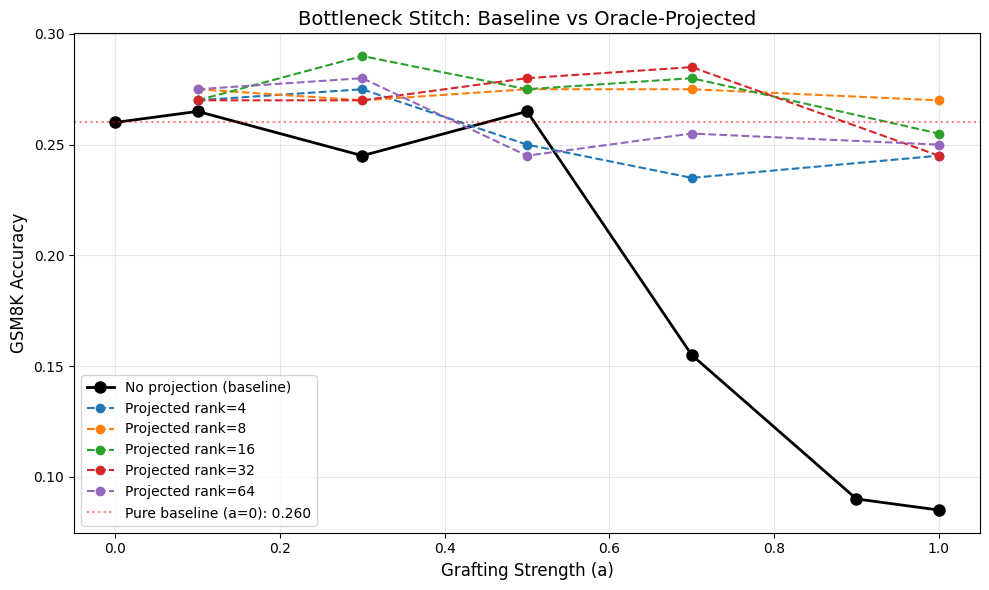


Plot saved to oracle_projected_comparison.png


In [33]:
# Summary + plot
 
print("\n" + "=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)
 
print("\nBaseline (no projection):")
for strength in STRENGTHS:
    key = f"baseline_s{strength}"
    if key in all_results:
        print(f"  a={strength:.1f}: {all_results[key]:.3f}")
 
print("\nOracle-projected:")
for rank in RANKS_TO_TEST:
    for strength in [0.1, 0.3, 0.5, 0.7, 1.0]:
        key = f"proj_r{rank}_s{strength}"
        if key in all_results:
            print(f"  rank={rank:>4d}, a={strength:.1f}: {all_results[key]:.3f}")
 
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
 
# Baseline curve
baseline_accs = [all_results.get(f"baseline_s{s}", 0) for s in STRENGTHS]
ax.plot(STRENGTHS, baseline_accs, 'ko-', linewidth=2, markersize=8, label='No projection (baseline)')
 
# Projected curves
proj_strengths = [0.1, 0.3, 0.5, 0.7, 1.0]
for rank in RANKS_TO_TEST:
    accs = [all_results.get(f"proj_r{rank}_s{s}", None) for s in proj_strengths]
    if any(a is not None for a in accs):
        ax.plot(proj_strengths, accs, 'o--', markersize=6, label=f'Projected rank={rank}')
 
ax.axhline(y=all_results.get("baseline_s0", 0), color='r', linestyle=':', alpha=0.5,
           label=f'Pure baseline (a=0): {all_results.get("baseline_s0", 0):.3f}')
ax.set_xlabel('Grafting Strength (a)', fontsize=12)
ax.set_ylabel('GSM8K Accuracy', fontsize=12)
ax.set_title('Bottleneck Stitch: Baseline vs Oracle-Projected', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('oracle_projected_comparison.png', dpi=150)
plt.show()
 
print("\nPlot saved to oracle_projected_comparison.png")
 

In [34]:
# [Phase 2] 2B-IT baseline — north star
#
# Run gemma-2-2b-it on the same 1000 GSM8K test problems, no stitch.
# This gives the target accuracy the oracle stitch is aiming to match.
# Rationale (from doc, integrity section): 'We should probably also evaluate
# IT 2B as well since we use it for the oracle stitch. Not sure if we can
# truly claim positive results unless we beat that baseline.'

import re

def evaluate_model_gsm8k_plain(model, tokenizer, samples, batch_size=8,
                                max_new_tokens=400, label="model"):
    """
    Evaluate a model on GSM8K without any stitch or hook.
    Reuses the same prompt format and answer extraction as the stitch eval.
    """
    correct, total = 0, 0
    model.eval()
    print(f"\nEvaluating {label} on {len(samples)} GSM8K problems...")

    for i in tqdm(range(0, len(samples), batch_size), desc=label):
        batch_samples = samples[i : i + batch_size]
        prompts = [generate_gsm8k_prompt(s['question']) for s in batch_samples]
        correct_answers = [extract_numerical_answer(s['answer']) for s in batch_samples]

        inputs = tokenizer(
            prompts, return_tensors="pt", padding=True,
            truncation=True, max_length=512
        ).to(device)

        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        responses = tokenizer.batch_decode(
            generated_ids[:, inputs['input_ids'].shape[1]:],
            skip_special_tokens=True
        )

        for j, response in enumerate(responses):
            predicted = extract_numerical_answer(response)
            ca = correct_answers[j]
            if predicted is not None and ca is not None and abs(predicted - ca) < 0.01:
                correct += 1
            total += 1

        if i == 0 or (i // batch_size) % 25 == 0:
            print(f"  [{total}/{len(samples)}] running acc = {correct/total:.3f}")

    accuracy = correct / total if total > 0 else 0.0
    print(f"-> {label} accuracy: {accuracy:.3f} ({correct}/{total})")
    return accuracy


# Load the same 1000-sample eval set used in the sweep
print("Loading 1000-sample GSM8K test set for 2B-IT baseline...")
gsm8k_test_1k = load_dataset("openai/gsm8k", "main", split="test")
eval_samples_1k = list(gsm8k_test_1k.select(range(200)))

# Load 2B-IT
print("Loading gemma-2-2b-it for baseline evaluation...")
model_it_eval = AutoModelForCausalLM.from_pretrained(
    "google/gemma-2-2b-it",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True
)
for param in model_it_eval.parameters():
    param.requires_grad = False

it_accuracy = evaluate_model_gsm8k_plain(
    model_it_eval, tokenizer, eval_samples_1k,
    batch_size=EVAL_BATCH_SIZE,
    max_new_tokens=MAX_NEW_TOKENS,
    label="gemma-2-2b-it (Phase 2 baseline)"
)

print("Unloading 2B-IT eval model...")
del model_it_eval
clear_memory()

print(f"\n{'='*60}")
print(f"Phase 2 result — gemma-2-2b-it (no stitch): {it_accuracy:.3f}")
print(f"This is the north-star target for the oracle stitch to match/beat.")
print(f"{'='*60}")


Loading 1000-sample GSM8K test set for 2B-IT baseline...
Loading gemma-2-2b-it for baseline evaluation...


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]


Evaluating gemma-2-2b-it (Phase 2 baseline) on 200 GSM8K problems...


gemma-2-2b-it (Phase 2 baseline):   0%|          | 0/25 [00:00<?, ?it/s]

  [8/200] running acc = 0.250
-> gemma-2-2b-it (Phase 2 baseline) accuracy: 0.535 (107/200)
Unloading 2B-IT eval model...

Phase 2 result — gemma-2-2b-it (no stitch): 0.535
This is the north-star target for the oracle stitch to match/beat.


In [35]:
def evaluate_gsm8k_sae_roundtrip(model_a, sae_a, tokenizer, samples,
                                 strength=1.0, batch_size=EVAL_BATCH_SIZE):
    """Control: graft = sae_a.decode(sae_a.encode(2B's OWN L20 act)). No 9B, no stitch.
    Collapse here => SAE reconstruction fidelity is the bottleneck, not the stitch."""
    correct = total = 0
    target_layer = model_a.model.layers[STITCH_LAYER_A]
    target_layer._forward_hooks.clear()
    hook = target_layer.register_forward_hook(dynamic_grafting_hook_projected)
    grafting_context['oracle_basis'] = None
    grafting_context['strength'] = strength
    model_a.eval(); sae_a.eval()
    try:
        for i in tqdm(range(0, len(samples), batch_size), desc=f"SAE-rt s={strength}"):
            batch = samples[i:i+batch_size]
            prompts = [generate_gsm8k_prompt(s['question']) for s in batch]
            gold = [extract_numerical_answer(s['answer']) for s in batch]
            inputs = tokenizer(prompts, return_tensors="pt", padding=True,
                               truncation=True, max_length=512).to(device)
            with torch.no_grad():
                out_a = model_a.model(inputs['input_ids'],
                                      attention_mask=inputs['attention_mask'],
                                      output_hidden_states=True)
                h_a = out_a.hidden_states[STITCH_LAYER_A + 1]
                bs, sl, hd = h_a.shape
                rt = sae_a.decode(sae_a.encode(h_a.view(-1, hd))).view(bs, sl, -1)
                grafting_context['current_grafted_activation'] = rt
                gen = model_a.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS,
                                       do_sample=False, pad_token_id=tokenizer.eos_token_id)
            resp = tokenizer.batch_decode(gen[:, inputs['input_ids'].shape[1]:],
                                          skip_special_tokens=True)
            for j, r in enumerate(resp):
                p = extract_numerical_answer(r)
                correct += int(p is not None and gold[j] is not None and abs(p - gold[j]) < 0.01)
                total += 1
    finally:
        hook.remove()
    acc = correct / total if total else 0.0
    print(f"-> SAE round-trip strength {strength}: acc = {acc:.3f} ({correct}/{total})")
    return acc

for s in [0.5, 1.0]:
    evaluate_gsm8k_sae_roundtrip(model_a, sae_a, tokenizer, evaluation_samples_sweep, strength=s)

SAE-rt s=0.5:   0%|          | 0/25 [00:00<?, ?it/s]

-> SAE round-trip strength 0.5: acc = 0.250 (50/200)


SAE-rt s=1.0:   0%|          | 0/25 [00:00<?, ?it/s]

-> SAE round-trip strength 1.0: acc = 0.145 (29/200)


In [37]:
rt_samples = list(load_dataset("openai/gsm8k", "main", split="test").select(range(500)))
rt_curve = {s: evaluate_gsm8k_sae_roundtrip(model_a, sae_a, tokenizer, rt_samples, strength=s)
            for s in [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]}
print(rt_curve)

SAE-rt s=0.0:   0%|          | 0/63 [00:00<?, ?it/s]

-> SAE round-trip strength 0.0: acc = 0.270 (135/500)


SAE-rt s=0.3:   0%|          | 0/63 [00:00<?, ?it/s]

-> SAE round-trip strength 0.3: acc = 0.246 (123/500)


SAE-rt s=0.5:   0%|          | 0/63 [00:00<?, ?it/s]

...

-> SAE round-trip strength 0.7: acc = 0.216 (108/500)


SAE-rt s=0.9:   0%|          | 0/63 [00:00<?, ?it/s]

-> SAE round-trip strength 0.9: acc = 0.186 (93/500)


SAE-rt s=1.0:   0%|          | 0/63 [00:00<?, ?it/s]

-> SAE round-trip strength 1.0: acc = 0.156 (78/500)
{0.0: 0.27, 0.3: 0.246, 0.5: 0.242, 0.7: 0.216, 0.9: 0.186, 1.0: 0.156}


PC0: max|cos|=0.894  (0.0% of random dirs match/exceed it)
PC1: max|cos|=0.193  (0.0% of random dirs match/exceed it)
PC2: max|cos|=0.253  (0.0% of random dirs match/exceed it)
PC3: max|cos|=0.179  (0.0% of random dirs match/exceed it)
PC4: max|cos|=0.312  (0.0% of random dirs match/exceed it)
PC5: max|cos|=0.391  (0.0% of random dirs match/exceed it)
random: mean=0.086  95th=0.097  max=0.114


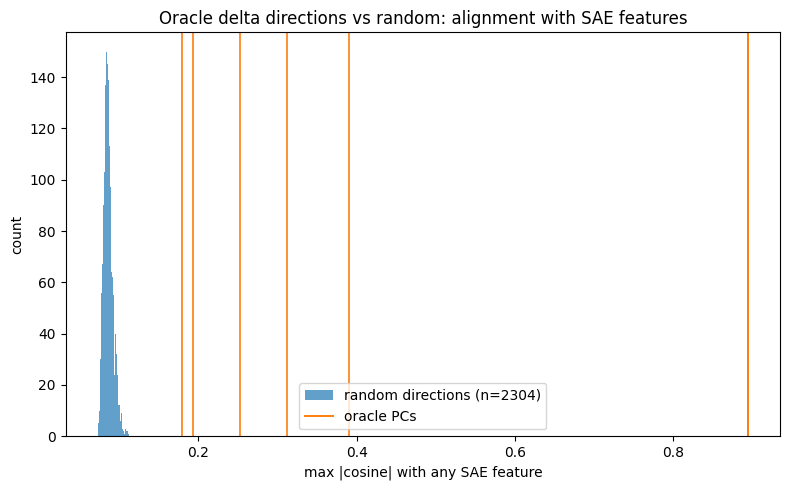

In [38]:
import numpy as np, matplotlib.pyplot as plt
dev = principal_components.device
Wd = sae_a.W_dec.detach().float().to(dev)
Wn = Wd / Wd.norm(dim=1, keepdim=True)                       # [16384, 2304] unit feature dirs

# Random directions = the SAME random_basis columns from Ablation 1 (cell 19)
R = random_basis.T.float().to(dev)                           # [2304, 2304], rows = random dirs
R = R / R.norm(dim=1, keepdim=True)
rand_maxcos = (R @ Wn.T).abs().max(dim=1).values.cpu().numpy()   # max|cos| per random dir

K = 6
PC = principal_components[:, :K].T.float().to(dev)
PC = PC / PC.norm(dim=1, keepdim=True)
orac_maxcos = (PC @ Wn.T).abs().max(dim=1).values.cpu().numpy()  # max|cos| per oracle PC

for k in range(K):
    pct = (rand_maxcos >= orac_maxcos[k]).mean() * 100
    print(f"PC{k}: max|cos|={orac_maxcos[k]:.3f}  ({pct:.1f}% of random dirs match/exceed it)")
print(f"random: mean={rand_maxcos.mean():.3f}  95th={np.percentile(rand_maxcos,95):.3f}  max={rand_maxcos.max():.3f}")

plt.figure(figsize=(8,5))
plt.hist(rand_maxcos, bins=50, alpha=0.7, label=f"random directions (n={len(rand_maxcos)})")
for k in range(K):
    plt.axvline(orac_maxcos[k], color='C1', lw=1.4, alpha=0.85)
plt.axvline(orac_maxcos[0], color='C1', lw=1.4, label="oracle PCs")
plt.xlabel("max |cosine| with any SAE feature"); plt.ylabel("count")
plt.title("Oracle delta directions vs random: alignment with SAE features")
plt.legend(); plt.tight_layout(); plt.savefig("oracle_vs_random_cosine.png", dpi=150); plt.show()

In [39]:
import random
import torch, torch.nn as nn, torch.nn.functional as F
from tqdm.auto import tqdm

class RawResidualStitch(nn.Module):
    """Direct 9B-residual -> 2B-residual map. NO sae_b.encode / sae_a.decode anywhere."""
    def __init__(self, d_b, d_a, hidden=2048):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_b, hidden), nn.GELU(), nn.Linear(hidden, d_a))
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x):                       # [..., d_b] -> [..., d_a]
        return self.net(x)

def train_raw_residual_stitch(model_a, model_b, raw_stitch, dataloader,
                              num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, weight_decay=0.01,
                              strength_min=STRENGTH_SAMPLE_MIN, strength_max=STRENGTH_SAMPLE_MAX,
                              first_n=15):
    print(f"Training RawResidualStitch (NO SAE) | {num_epochs} epochs, KL, first-{first_n}, prompt-graft")
    opt = torch.optim.AdamW(raw_stitch.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs*len(dataloader))
    target_layer = model_a.model.layers[STITCH_LAYER_A]
    target_layer._forward_hooks.clear()
    handle = target_layer.register_forward_hook(masked_grafting_hook)   # reuse training hook
    grafting_context['oracle_basis'] = None
    grafting_context['rescale_graft'] = False
    raw_stitch.train()
    try:
        for epoch in range(num_epochs):
            tot, nb = 0.0, 0
            pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
            for batch in pbar:
                tokens = batch['input_ids'].to(device); attn = batch['attention_mask'].to(device)
                prompt_mask = batch['prompt_mask'].to(device); sol = batch['sol_token_mask'].to(device)
                pred = torch.zeros_like(sol); pred[:, :-1] = sol[:, 1:]
                firstn = pred.bool() & (pred.cumsum(dim=1) <= first_n)
                mask_flat = firstn.reshape(-1).bool()
                if mask_flat.sum() == 0:
                    continue
                opt.zero_grad()
                s = random.uniform(strength_min, strength_max)
                grafting_context['current_grafted_activation'] = None
                with torch.no_grad():
                    tout = model_b(tokens, attention_mask=attn, output_hidden_states=True, use_cache=False)
                    teacher_logits = tout.logits
                    teacher_act = tout.hidden_states[STITCH_LAYER_B + 1]      # [B,T,3584]
                grafted = raw_stitch(teacher_act.float())                     # [B,T,2304], grads flow
                grafting_context['strength'] = s
                grafting_context['current_grafted_activation'] = grafted
                grafting_context['graft_position_mask'] = prompt_mask
                logits = model_a(tokens, attention_mask=attn, use_cache=False).logits
                V = logits.size(-1)
                ga = logits.view(-1, V)[mask_flat].float()
                ta = teacher_logits.view(-1, V)[mask_flat].float()
                kl = F.kl_div(F.log_softmax(ga, -1), F.log_softmax(ta, -1),
                              reduction='batchmean', log_target=True)
                kl.backward()
                torch.nn.utils.clip_grad_norm_(raw_stitch.parameters(), 1.0)
                opt.step(); sched.step()
                tot += kl.item(); nb += 1
                pbar.set_postfix({'kl': f"{kl.item():.4f}", 's': f"{s:.2f}"})
            print(f"Epoch {epoch+1}: KL={tot/max(nb,1):.4f} ({nb} batches)")
    finally:
        handle.remove()
        grafting_context.update(strength=0.0, current_grafted_activation=None, graft_position_mask=None)
    return tot/max(nb,1)

In [40]:
def evaluate_gsm8k_raw(model_a, model_b, raw_stitch, tokenizer, samples,
                       strength=1.0, batch_size=EVAL_BATCH_SIZE):
    correct = total = 0
    target_layer = model_a.model.layers[STITCH_LAYER_A]
    target_layer._forward_hooks.clear()
    handle = target_layer.register_forward_hook(dynamic_grafting_hook_projected)
    grafting_context['oracle_basis'] = None; grafting_context['strength'] = strength
    model_a.eval(); model_b.eval(); raw_stitch.eval()
    try:
        for i in tqdm(range(0, len(samples), batch_size), desc=f"raw s={strength}"):
            b = samples[i:i+batch_size]
            prompts = [generate_gsm8k_prompt(x['question']) for x in b]
            gold = [extract_numerical_answer(x['answer']) for x in b]
            inputs = tokenizer(prompts, return_tensors="pt", padding=True,
                               truncation=True, max_length=512).to(device)
            with torch.no_grad():
                if strength > 0.0:
                    base_b = model_b.model if hasattr(model_b, 'model') else model_b
                    ob = base_b(inputs['input_ids'], attention_mask=inputs['attention_mask'],
                                output_hidden_states=True)
                    grafting_context['current_grafted_activation'] = raw_stitch(
                        ob.hidden_states[STITCH_LAYER_B + 1].float())
                else:
                    grafting_context['current_grafted_activation'] = None
                gen = model_a.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS,
                                       do_sample=False, pad_token_id=tokenizer.eos_token_id)
            resp = tokenizer.batch_decode(gen[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)
            for j, r in enumerate(resp):
                p = extract_numerical_answer(r)
                correct += int(p is not None and gold[j] is not None and abs(p-gold[j]) < 0.01)
                total += 1
    finally:
        handle.remove()
    acc = correct/total if total else 0.0
    print(f"-> RAW stitch strength {strength}: acc = {acc:.3f} ({correct}/{total})")
    return acc

In [41]:
clear_memory()
raw_stitch = RawResidualStitch(d_b=model_b.config.hidden_size,
                               d_a=model_a.config.hidden_size).to(device)   # 3584 -> 2304
train_raw_residual_stitch(model_a, model_b, raw_stitch, dataloader)
raw_results = {s: evaluate_gsm8k_raw(model_a, model_b, raw_stitch, tokenizer,
                                     evaluation_samples_sweep, strength=s)
               for s in [0.0, 0.3, 0.5, 0.7, 1.0]}
print(raw_results)

Training RawResidualStitch (NO SAE) | 8 epochs, KL, first-15, prompt-graft


Epoch 1/8:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 1: KL=0.1619 (1250 batches)


Epoch 2/8:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 2: KL=0.1313 (1250 batches)


...

-> RAW stitch strength 0.5: acc = 0.220 (44/200)


raw s=0.7:   0%|          | 0/25 [00:00<?, ?it/s]

-> RAW stitch strength 0.7: acc = 0.180 (36/200)


raw s=1.0:   0%|          | 0/25 [00:00<?, ?it/s]

-> RAW stitch strength 1.0: acc = 0.150 (30/200)
{0.0: 0.26, 0.3: 0.24, 0.5: 0.22, 0.7: 0.18, 1.0: 0.15}


In [42]:
import torch
Wd = sae_a.W_dec.detach().float().to(principal_components.device)
Wn = Wd / Wd.norm(dim=1, keepdim=True)
for k in range(6):
    pc = principal_components[:, k].float(); pc = pc / pc.norm()
    cos = Wn @ pc
    j = cos.abs().argmax().item()
    print(f"PC{k} (var={explained_var[k].item():.3f}): feature #{j}  cos={cos[j].item():+.3f}")

PC0 (var=0.180): feature #8684  cos=+0.894
PC1 (var=0.031): feature #15153  cos=-0.193
PC2 (var=0.027): feature #435  cos=+0.253
PC3 (var=0.025): feature #1264  cos=-0.179
PC4 (var=0.022): feature #5816  cos=-0.312
PC5 (var=0.019): feature #12748  cos=+0.391


In [43]:
# [Phase 0] Oracle delta collection — LEAKAGE FIX
#
# Previously: oracle deltas were collected from evaluation_samples (GSM8K test),
# meaning the first 100 eval problems were also used to build the oracle basis.
# Fix: collect deltas from GSM8K *train* split, which is a completely disjoint
# HF dataset split from the test split used for evaluation.
#
# NOTEBOOK ORDER NOTE: This cell must run BEFORE cell 10 (train call) if
# APPLY_ORACLE_IN_TRAINING=True. With APPLY_ORACLE_IN_TRAINING=False (current
# default) ordering relative to training doesn't matter, but placing it before
# training is recommended for clarity and future-proofing (Phase 3).

def collect_oracle_deltas_same_dim(model_s, model_t_it, tokenizer, samples,
                                    stitch_layer=20, batch_size=8,
                                    max_samples=100, max_seq_len=256):
    """
    Collect oracle deltas: (teacher_IT_hidden - student_base_hidden)
    at the stitch layer. Both models must share the same d_model.

    Args:
        model_s:     student model (gemma-2-2b base)
        model_t_it:  teacher model (gemma-2-2b-it, same architecture)
        samples:     list of dicts with a 'question' key (GSM8K-train rows)
        stitch_layer: layer index to extract hidden states from

    Returns:
        deltas: torch.Tensor [num_tokens, d_model]
    """
    model_s.eval()
    model_t_it.eval()
    all_deltas = []

    samples_to_use = samples[:max_samples]
    print(f"Collecting oracle deltas from {len(samples_to_use)} samples at layer {stitch_layer}...")

    for i in tqdm(range(0, len(samples_to_use), batch_size), desc="Collecting deltas"):
        batch = samples_to_use[i : i + batch_size]
        prompts = [generate_gsm8k_prompt(s["question"]) for s in batch]

        inputs = tokenizer(
            prompts, return_tensors="pt", padding=True,
            truncation=True, max_length=max_seq_len
        ).to(device)
        attention_mask = inputs["attention_mask"]

        with torch.no_grad():
            if hasattr(model_s, 'model'):
                out_s = model_s.model(
                    inputs['input_ids'],
                    attention_mask=inputs.get('attention_mask'),
                    output_hidden_states=True
                )
            else:
                out_s = model_s(
                    inputs['input_ids'],
                    attention_mask=inputs.get('attention_mask'),
                    output_hidden_states=True
                )
            h_s = out_s.hidden_states[stitch_layer + 1]  # [B, T, 2304]

            if hasattr(model_t_it, 'model'):
                out_t = model_t_it.model(
                    inputs['input_ids'],
                    attention_mask=inputs.get('attention_mask'),
                    output_hidden_states=True
                )
            else:
                out_t = model_t_it(
                    inputs['input_ids'],
                    attention_mask=inputs.get('attention_mask'),
                    output_hidden_states=True
                )
            h_t = out_t.hidden_states[stitch_layer + 1]  # [B, T, 2304]

        delta = (h_t - h_s).float()  # [B, T, 2304]
        for b in range(delta.shape[0]):
            real = attention_mask[b].bool()          # works for left- OR right-padding
            keep = attention_mask[b].nonzero(as_tuple=True)[0][1:]   # drop the first real token (BOS)
            all_deltas.append(delta[b, keep, :].cpu())

        del out_s, out_t, h_s, h_t, delta
        clear_memory()

    all_deltas = torch.cat(all_deltas, dim=0)  # [N_tokens, 2304]
    print(f"Collected {all_deltas.shape[0]} token deltas, dim={all_deltas.shape[1]}")
    return all_deltas


def fit_pca_on_deltas(deltas):
    """
    Fit PCA/SVD on collected oracle deltas.

    Returns:
        components:  [d_model, k] columns are principal directions
        S:           singular values
        explained:   explained variance ratio per component
    """
    print(f"\nFitting SVD on {deltas.shape[0]} deltas (dim={deltas.shape[1]})...")

    X = deltas.float()
    X = X - X.mean(dim=0, keepdim=True)  # center

    U, S, Vt = torch.linalg.svd(X, full_matrices=False)
    components = Vt.T  # [d_model, k]

    explained = (S ** 2) / (S ** 2).sum()

    print(f"Top-10 explained variance: {explained[:10].numpy()}")
    print(f"Cumulative top-32:  {explained[:32].sum():.4f}")
    print(f"Cumulative top-64:  {explained[:64].sum():.4f}")
    print(f"Cumulative top-128: {explained[:128].sum():.4f}")

    return components, S, explained


# ── Run oracle delta collection on GSM8K-train (disjoint from eval) ──────────
print("=" * 60)
print("ORACLE DELTA COLLECTION  [Phase 0: using GSM8K-train]")
print("=" * 60)

# Load N_ORACLE_SAMPLES rows from the train split
print(f"Loading {N_ORACLE_SAMPLES} examples from GSM8K-train for oracle fitting...")
gsm8k_train_for_oracle = load_dataset("openai/gsm8k", "main", split="train")
oracle_fit_samples = list(gsm8k_train_for_oracle.select(range(N_ORACLE_SAMPLES)))
print(f"Using GSM8K-train indices 0..{N_ORACLE_SAMPLES-1} for oracle (never overlaps test split)")

print("Temporarily loading gemma-2-2b-it for oracle deltas...")
# Offload the 9B (4-bit) teacher to CPU to free VRAM for the 2B-IT load below.
# NOTE: device moves on a bitsandbytes 4-bit model work on recent
# transformers+bitsandbytes but can raise on older versions, so guard it.
print("Offloading 9B model to CPU to free VRAM...")
try:
    model_b.to("cpu"); clear_memory()
    _model_b_offloaded = True
except Exception as e:
    print(f"  Could not offload 9B to CPU ({e}); leaving it on GPU.")
    _model_b_offloaded = False

model_it = AutoModelForCausalLM.from_pretrained(
    "google/gemma-2-2b-it",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True
)
for param in model_it.parameters():
    param.requires_grad = False

print("2B-IT loaded. Collecting oracle deltas from GSM8K-train...")

oracle_deltas = collect_oracle_deltas_same_dim(
    model_a, model_it, tokenizer,
    oracle_fit_samples,         # <-- train split, not evaluation_samples
    stitch_layer=STITCH_LAYER_A,
    batch_size=EVAL_BATCH_SIZE,
    max_samples=N_ORACLE_SAMPLES,
    max_seq_len=256,
)

principal_components, singular_values, explained_var = fit_pca_on_deltas(oracle_deltas)

print("Unloading 2B-IT and freeing delta memory...")
del model_it, oracle_deltas
clear_memory()

# Move the 9B teacher back to the GPU (only if it was actually offloaded above).
if _model_b_offloaded:
    model_b.to(device); clear_memory()

print(f"\nOracle PCA basis ready: shape={principal_components.shape}")
print(f"  d_model={principal_components.shape[0]}, max_rank={principal_components.shape[1]}")


ORACLE DELTA COLLECTION  [Phase 0: using GSM8K-train]
Loading 100 examples from GSM8K-train for oracle fitting...
Using GSM8K-train indices 0..99 for oracle (never overlaps test split)
Temporarily loading gemma-2-2b-it for oracle deltas...
Offloading 9B model to CPU to free VRAM...


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

2B-IT loaded. Collecting oracle deltas from GSM8K-train...


Collected 19345 token deltas, dim=2304

Fitting SVD on 19345 deltas (dim=2304)...
Top-10 explained variance: [0.08592946 0.03286178 0.03049438 0.02686035 0.02439322 0.02057789
 0.01950306 0.0181501  0.0171601  0.01538417]
Cumulative top-32:  0.5133
Cumulative top-64:  0.6714
Cumulative top-128: 0.8055
Unloading 2B-IT and freeing delta memory...

Oracle PCA basis ready: shape=torch.Size([2304, 2304])
  d_model=2304, max_rank=2304


PC0: max|cos|=0.835  (0.0% of random dirs match/exceed it)
PC1: max|cos|=0.199  (0.0% of random dirs match/exceed it)
PC2: max|cos|=0.263  (0.0% of random dirs match/exceed it)
PC3: max|cos|=0.242  (0.0% of random dirs match/exceed it)
PC4: max|cos|=0.254  (0.0% of random dirs match/exceed it)
PC5: max|cos|=0.187  (0.0% of random dirs match/exceed it)
random: mean=0.086  95th=0.097  max=0.114


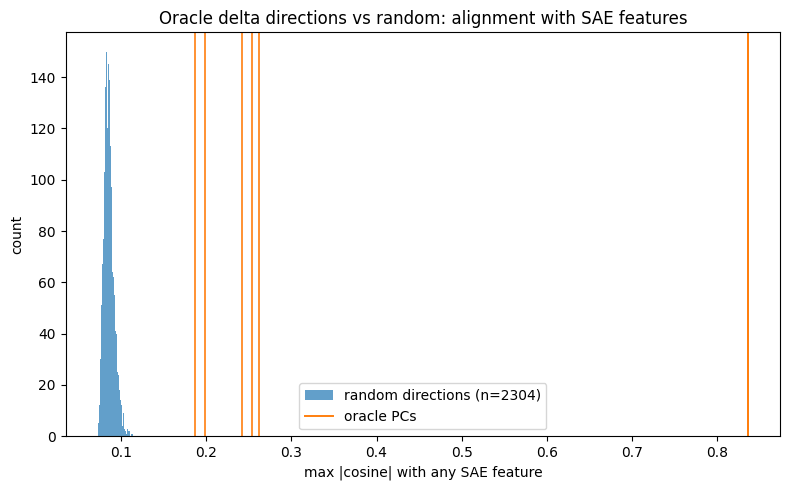

In [44]:
import numpy as np, matplotlib.pyplot as plt
dev = principal_components.device
Wd = sae_a.W_dec.detach().float().to(dev)
Wn = Wd / Wd.norm(dim=1, keepdim=True)                       # [16384, 2304] unit feature dirs

# Random directions = the SAME random_basis columns from Ablation 1 (cell 19)
R = random_basis.T.float().to(dev)                           # [2304, 2304], rows = random dirs
R = R / R.norm(dim=1, keepdim=True)
rand_maxcos = (R @ Wn.T).abs().max(dim=1).values.cpu().numpy()   # max|cos| per random dir

K = 6
PC = principal_components[:, :K].T.float().to(dev)
PC = PC / PC.norm(dim=1, keepdim=True)
orac_maxcos = (PC @ Wn.T).abs().max(dim=1).values.cpu().numpy()  # max|cos| per oracle PC

for k in range(K):
    pct = (rand_maxcos >= orac_maxcos[k]).mean() * 100
    print(f"PC{k}: max|cos|={orac_maxcos[k]:.3f}  ({pct:.1f}% of random dirs match/exceed it)")
print(f"random: mean={rand_maxcos.mean():.3f}  95th={np.percentile(rand_maxcos,95):.3f}  max={rand_maxcos.max():.3f}")

plt.figure(figsize=(8,5))
plt.hist(rand_maxcos, bins=50, alpha=0.7, label=f"random directions (n={len(rand_maxcos)})")
for k in range(K):
    plt.axvline(orac_maxcos[k], color='C1', lw=1.4, alpha=0.85)
plt.axvline(orac_maxcos[0], color='C1', lw=1.4, label="oracle PCs")
plt.xlabel("max |cosine| with any SAE feature"); plt.ylabel("count")
plt.title("Oracle delta directions vs random: alignment with SAE features")
plt.legend(); plt.tight_layout(); plt.savefig("oracle_vs_random_cosine.png", dpi=150); plt.show()

In [45]:
import torch
Wd = sae_a.W_dec.detach().float().to(principal_components.device)
Wn = Wd / Wd.norm(dim=1, keepdim=True)
for k in range(6):
    pc = principal_components[:, k].float(); pc = pc / pc.norm()
    cos = Wn @ pc
    j = cos.abs().argmax().item()
    print(f"PC{k} (var={explained_var[k].item():.3f}): feature #{j}  cos={cos[j].item():+.3f}")

PC0 (var=0.086): feature #8684  cos=-0.835
PC1 (var=0.033): feature #1642  cos=+0.199
PC2 (var=0.030): feature #12748  cos=+0.263
PC3 (var=0.027): feature #5816  cos=-0.242
PC4 (var=0.024): feature #5816  cos=-0.254
PC5 (var=0.021): feature #1039  cos=-0.187


In [46]:
import torch, json
torch.save({'principal_components': principal_components.detach().cpu(),
            'explained_var': explained_var}, 'oracle_pca.pt')   # so you never re-run the 2B-IT collection
results = {}
for name in ['all_results', 'raw_results', 'rt_curve']:
    d = globals().get(name)
    if isinstance(d, dict):
        results[name] = {str(k): float(v) for k, v in d.items()}
with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('saved oracle_pca.pt + results.json:', list(results.keys()))

saved oracle_pca.pt + results.json: ['all_results', 'raw_results', 'rt_curve']


In [47]:
!zip -j artifacts.zip *.ipynb *.pth *.pt *.json *.png ; ls -la artifacts.zip

/bin/bash: line 1: zip: command not found
ls: cannot access 'artifacts.zip': No such file or directory


In [48]:
import os, glob, json, zipfile, torch

# --- write memory-only things to disk (skips anything already saved) ---
if 'raw_stitch' in globals():
    torch.save(raw_stitch.state_dict(), 'raw_residual_stitch.pth')
if not os.path.exists('bottleneck_stitch.pth') and 'stitch_model' in globals():
    torch.save(stitch_model.state_dict(), 'bottleneck_stitch.pth')
if 'principal_components' in globals():
    torch.save({'principal_components': principal_components.detach().cpu(),
                'explained_var': globals().get('explained_var')}, 'oracle_pca.pt')
results = {}
for name in ['all_results', 'raw_results', 'rt_curve']:
    d = globals().get(name)
    if isinstance(d, dict):
        results[name] = {str(k): float(v) for k, v in d.items()}
if results:
    json.dump(results, open('results.json', 'w'), indent=2)

# --- bundle with Python's zipfile (no system 'zip' needed) ---
files = sorted({f for pat in ['*.ipynb','*.pth','*.pt','*.json','*.png'] for f in glob.glob(pat)})
with zipfile.ZipFile('artifacts.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for f in files:
        z.write(f, os.path.basename(f))
print('bundled into artifacts.zip:')
for f in files:
    print(f'   {f:32s} {os.path.getsize(f):>12,} bytes')
print('artifacts.zip:', os.path.getsize('artifacts.zip'), 'bytes')

bundled into artifacts.zip:
   SAE_Negative_Case_Result.ipynb        482,751 bytes
   bottleneck_stitch.pth              16,912,665 bytes
   oracle_pca.pt                      21,244,797 bytes
   oracle_projected_comparison.png       144,903 bytes
   oracle_vs_random_cosine.png            46,645 bytes
   raw_residual_stitch.pth            48,254,613 bytes
   results.json                            2,734 bytes
artifacts.zip: 80162724 bytes
